# EDA Workbook
Input source: raw Excel `DB for DTM Project.xlsx` (sheet `Associazioni Cod. Art. - LOB`)

This workbook is structured following:
1. CRISP-DM **Data Understanding** (collection, description, exploration, quality verification)
2. **Data Preparation** steps (selection, cleansing, construction, integration, formatting)

Each DU/DP step includes at least one data visualization.


## 1) Setup
Import libraries, set notebook options, and initialize shared state.


In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 240)

plt.style.use('default')
RANDOM_STATE = 42

stage_sizes = {}


## 2) Load Dataset
Load the **raw Excel** sheet and verify shape/columns.


In [ ]:
NOTEBOOK_DIR = Path.cwd()
EXCEL_CANDIDATES = [
    NOTEBOOK_DIR / 'DB for DTM Project.xlsx',
    NOTEBOOK_DIR.parent / 'DB for DTM Project.xlsx',
    Path('C:/Users/sveta/Documents/vem-product/DB for DTM Project.xlsx'),
]

DATA_PATH = next((p for p in EXCEL_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('DB for DTM Project.xlsx not found in expected locations.')

RAW_SHEET_NAME = 'Associazioni Cod. Art. - LOB'
df_raw = pd.read_excel(DATA_PATH, sheet_name=RAW_SHEET_NAME)
df_raw.columns = [str(c).strip() for c in df_raw.columns]

df = df_raw.copy()
stage_sizes['raw'] = len(df)

print(f'DATA_PATH: {DATA_PATH}')
print(f'RAW_SHEET_NAME: {RAW_SHEET_NAME}')
print(f'shape: {df.shape}')
print(f'columns: {list(df.columns)}')
display(df.head(10))


DATA_PATH: c:\Users\sveta\Documents\vem-product\DB for DTM Project.xlsx
RAW_SHEET_NAME: Associazioni Cod. Art. - LOB
shape: (22655, 5)
columns: ['Codice Articolo', 'Lob Associata', 'Nome LOB', 'Inventario', 'Descrizione Articolo']


,Codice Articolo,Lob Associata,Nome LOB,Inventario,Descrizione Articolo
0,000050,1002,CABLAGGIO ALTERNATIVO,Inventario,PATCH CORD UTP 2/RJ45 CAT5E MT2
1,000081,1002,CABLAGGIO ALTERNATIVO,Inventario,cab - cf54/150ez passerella a filo 3m
2,‎000411AA230621QMANE,3004,CLOUD VARIE HW,Inventario,QUARKZMAN 30pz Ultra Sottile Telefono Leva Ape...
3,00054569,3004,CLOUD VARIE HW,Inventario,adattatore vga-hdmi
4,000ERIDT29,4002,ALTRO MATERIALE,Inventario,ERICSSON DT290/292 BATTERIA CORDLESS
5,001DELTA-E,24001,BUILDING AUTOMATION,Inventario,FOTOCELLULA CAME DA ESTERNO COPPIA RICEVITORE/...
6,0021X145,3004,CLOUD VARIE HW,Inventario,CUSTODIA MORBIDA DCC-80
7,002349147,3004,CLOUD VARIE HW,Inventario,E350 E352DN 3 ANNI TOTALI (1+2)
8,002R3G6,4002,ALTRO MATERIALE,Inventario,CELLULARE NOKIA E52 NAVY
9,00413.CK.B,1002,CABLAGGIO ALTERNATIVO,Inventario,Presa mult. 3P BIANCA


## 3) Detect Semantic Columns
Resolve key fields used in DU/DP flow.


In [ ]:
def normalize_colname(name: str) -> str:
    return re.sub(r'\s+', ' ', str(name).strip().lower())


def find_column(columns, patterns):
    normalized = {c: normalize_colname(c) for c in columns}
    for pattern in patterns:
        regex = re.compile(pattern, flags=re.IGNORECASE)
        for col, norm in normalized.items():
            if regex.search(norm):
                return col
    return None


code_col = find_column(df.columns, [r'cod(ic|e|ice)?', r'code', r'item'])
desc_col = find_column(df.columns, [r'descr(izione)?', r'description', r'keyword'])
inventory_col = find_column(df.columns, [r'inventario', r'inventory'])
lob_raw_col = 'Lob Associata' if 'Lob Associata' in df.columns else find_column(df.columns, [r'lob associata', r'lob'])

# DU runs on raw target; DP-2 will create/update cleaned target.
target_col_raw = lob_raw_col
target_col_clean = 'Lob Associata Cleaned'
target_col = target_col_raw

required = [code_col, desc_col, lob_raw_col]
if any(c is None for c in required):
    raise ValueError(f'Missing required semantic columns: code={code_col}, desc={desc_col}, lob_raw={lob_raw_col}')

column_map = pd.DataFrame(
    {
        'semantic_role': [
            'code_col', 'desc_col', 'inventory_col', 'lob_raw_col',
            'target_col_raw', 'target_col_clean', 'target_col_current'
        ],
        'column_name': [
            code_col, desc_col, inventory_col, lob_raw_col,
            target_col_raw, target_col_clean, target_col
        ],
    }
)

display(column_map)


,semantic_role,column_name
0,code_col,Codice Articolo
1,desc_col,Descrizione Articolo
2,inventory_col,Inventario
3,lob_raw_col,Lob Associata
4,target_col_raw,Lob Associata
5,target_col_clean,Lob Associata Cleaned
6,target_col_current,Lob Associata


## DU-1) Initial Data Collection
Confirm scope and class coverage from collected data.

Visualization:
- class coverage by target,
- coverage by inventory (if available).


data_path           c:\Users\sveta\Documents\vem-product\DB for DT...
rows                                                            22655
columns                                                             5
target_unique                                                     117
inventory_unique                                                    3
Name: value, dtype: object

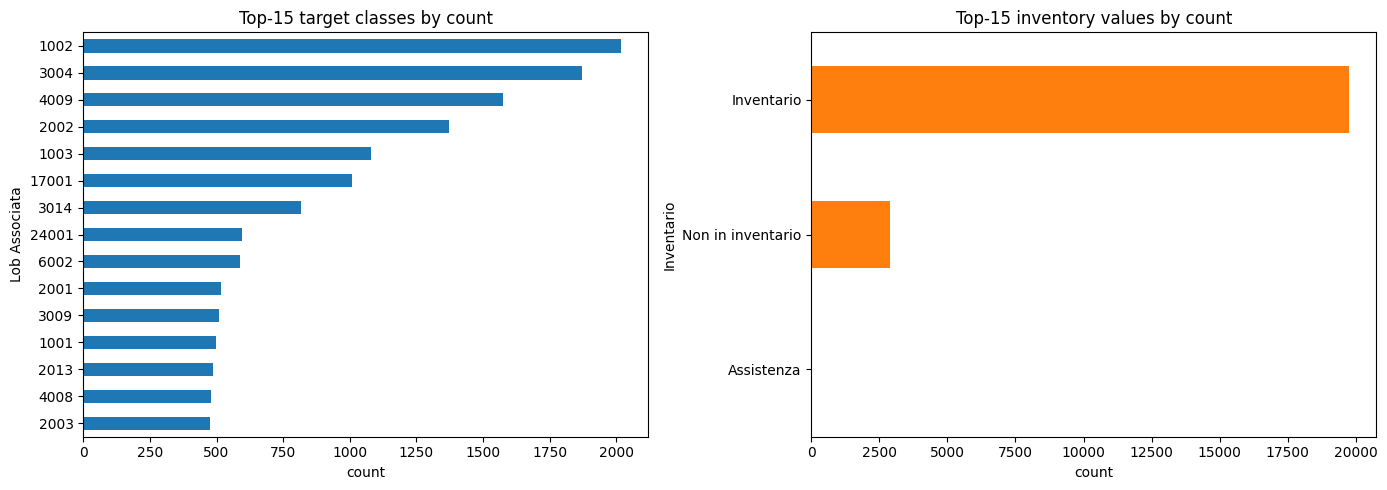

In [ ]:
collection_overview = {
    'data_path': str(DATA_PATH),
    'rows': int(len(df)),
    'columns': int(len(df.columns)),
    'target_unique': int(df[target_col].nunique(dropna=True)),
    'inventory_unique': int(df[inventory_col].nunique(dropna=True)) if inventory_col else 0,
}

display(pd.Series(collection_overview, name='value'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

(
    df[target_col]
    .value_counts(dropna=False)
    .head(15)
    .sort_values()
    .plot(kind='barh', ax=axes[0], color='#1f77b4')
)
axes[0].set_title('Top-15 target classes by count')
axes[0].set_xlabel('count')
axes[0].set_ylabel(target_col)

if inventory_col:
    (
        df[inventory_col]
        .astype(str)
        .value_counts(dropna=False)
        .head(15)
        .sort_values()
        .plot(kind='barh', ax=axes[1], color='#ff7f0e')
    )
    axes[1].set_title('Top-15 inventory values by count')
    axes[1].set_xlabel('count')
    axes[1].set_ylabel(inventory_col)
else:
    axes[1].axis('off')
    axes[1].text(0.1, 0.5, 'inventory column not found', fontsize=12)

plt.tight_layout()
plt.show()


## DU-2) Describe Data
Profile schema, nulls, cardinality, and basic structure.

Visualization:
- missing percentage by column,
- cardinality by column.


,column,dtype,non_null,null_count,null_pct,n_unique
4,Descrizione Articolo,object,22595,60,0.265,21283
0,Codice Articolo,object,22655,0,0.000,22655
1,Lob Associata,int64,22655,0,0.000,117
2,Nome LOB,object,22655,0,0.000,115
3,Inventario,object,22655,0,0.000,3


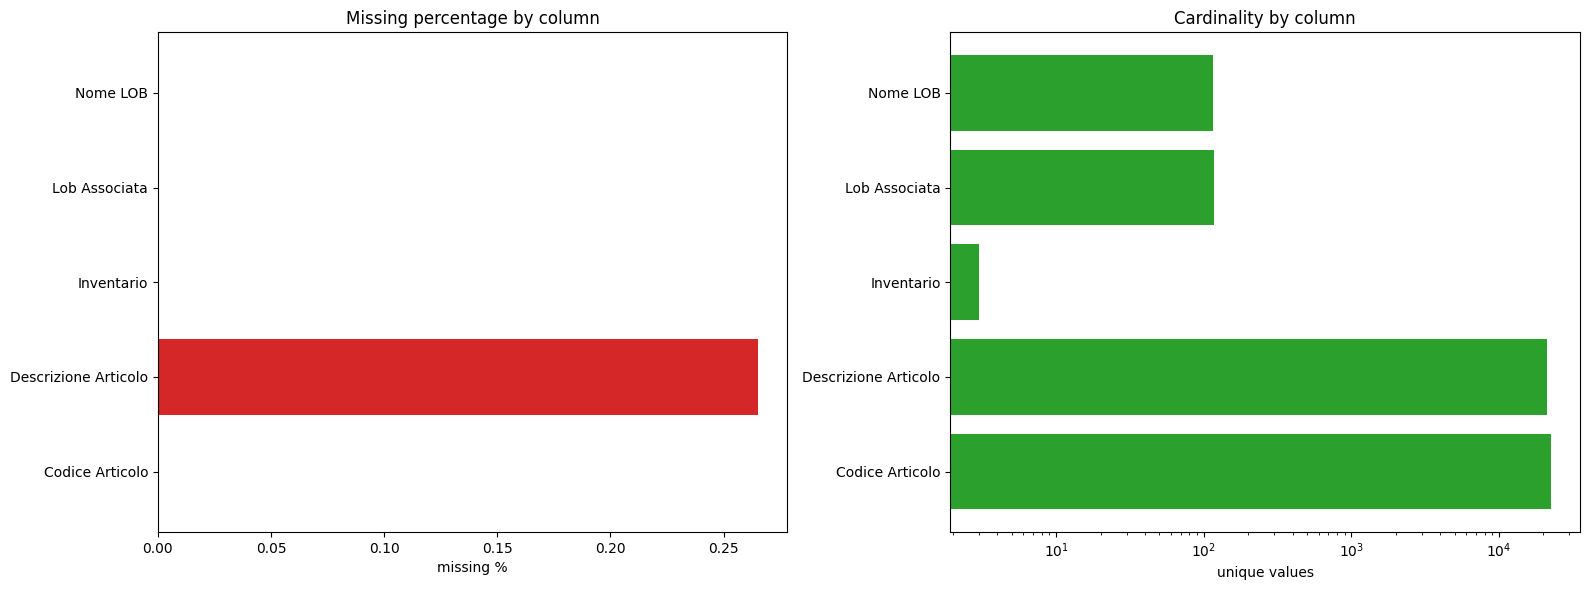

In [ ]:
profile_df = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(t) for t in df.dtypes.values],
    'non_null': df.notna().sum().values,
    'null_count': df.isna().sum().values,
    'null_pct': (df.isna().mean() * 100).round(3).values,
    'n_unique': df.nunique(dropna=True).values,
}).sort_values(['null_count', 'n_unique'], ascending=[False, False])

display(profile_df)

plot_df = profile_df.sort_values('column')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(plot_df['column'], plot_df['null_pct'], color='#d62728')
axes[0].set_title('Missing percentage by column')
axes[0].set_xlabel('missing %')

axes[1].barh(plot_df['column'], plot_df['n_unique'], color='#2ca02c')
axes[1].set_title('Cardinality by column')
axes[1].set_xlabel('unique values')
if (plot_df['n_unique'] > 100).any():
    axes[1].set_xscale('log')

plt.tight_layout()
plt.show()


## DU-3) Explore Data
Analyze distributions and early relationships between candidate signals and target.

Visualizations:
- target Pareto chart,
- prefix vs target heatmap.


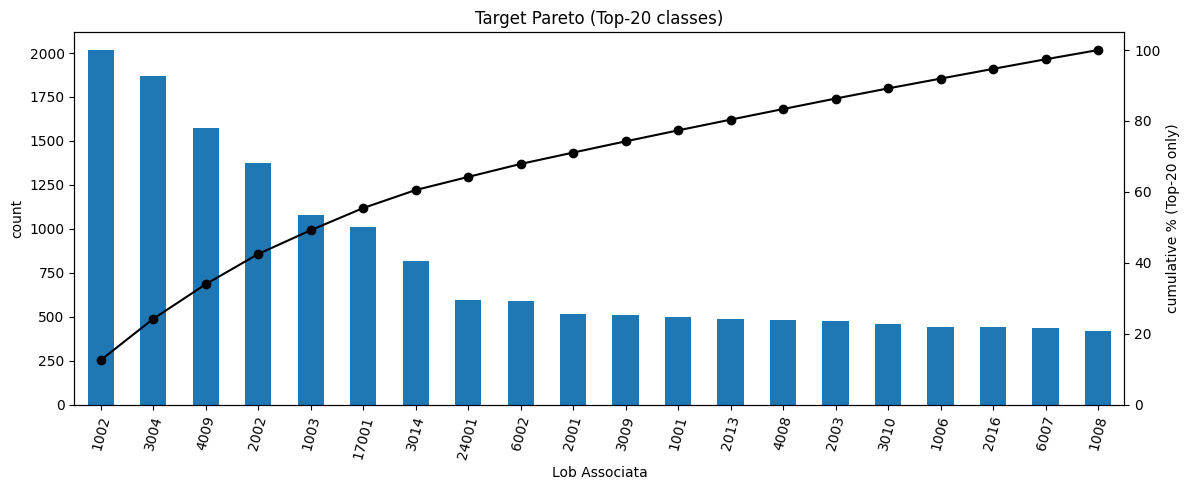

In [ ]:
explore_cols = [code_col, desc_col, target_col]
if inventory_col and inventory_col not in explore_cols:
    explore_cols.append(inventory_col)

explore_df = df[explore_cols].copy()

code_s = explore_df[code_col].astype(str).str.strip().str.upper()
desc_s = explore_df[desc_col].astype(str)

alpha_prefix = code_s.str.extract(r'^([A-Z]+)', expand=False)
num_prefix2 = code_s.str.extract(r'^(\d{2})', expand=False)
explore_df['code_prefix'] = alpha_prefix.fillna(num_prefix2).fillna('OTHER')
explore_df['code_len'] = code_s.str.len()
explore_df['desc_token_count'] = desc_s.str.findall(r'[A-Za-z0-9]+').str.len()

pareto_counts = explore_df[target_col].value_counts().head(20)
pareto_cum = pareto_counts.cumsum() / pareto_counts.sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
pareto_counts.plot(kind='bar', ax=ax1, color='#1f77b4')
ax1.set_title('Target Pareto (Top-20 classes)')
ax1.set_ylabel('count')
ax1.set_xlabel(target_col)
ax1.tick_params(axis='x', rotation=75)

ax2 = ax1.twinx()
ax2.plot(range(len(pareto_counts)), pareto_cum.values, color='black', marker='o', linewidth=1.5)
ax2.set_ylabel('cumulative % (Top-20 only)')
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()


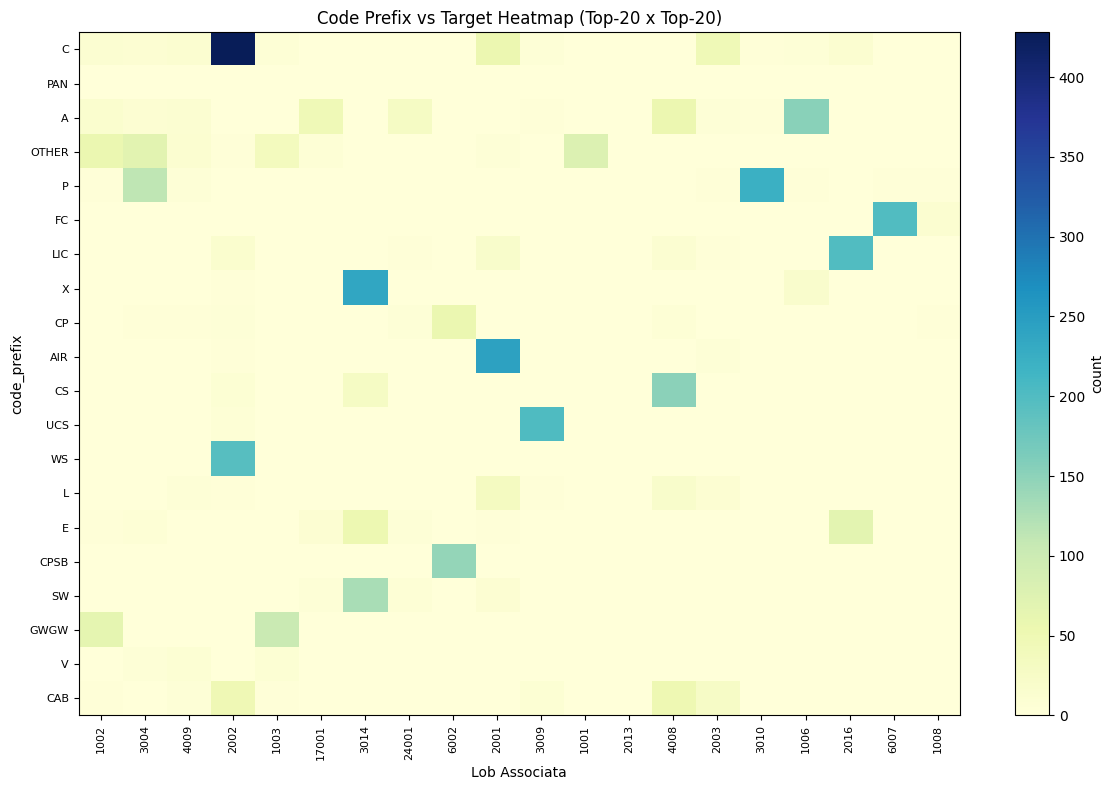

In [ ]:
cross = pd.crosstab(explore_df['code_prefix'], explore_df[target_col])

if cross.empty:
    print('No data for prefix/target heatmap.')
else:
    top_prefix = cross.sum(axis=1).nlargest(20).index
    top_target = cross.sum(axis=0).nlargest(20).index
    heat = cross.loc[top_prefix, top_target]

    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(heat.values, aspect='auto', cmap='YlGnBu')
    ax.set_title('Code Prefix vs Target Heatmap (Top-20 x Top-20)')
    ax.set_xlabel(target_col)
    ax.set_ylabel('code_prefix')
    ax.set_xticks(range(len(heat.columns)))
    ax.set_xticklabels([str(x) for x in heat.columns], rotation=90, fontsize=8)
    ax.set_yticks(range(len(heat.index)))
    ax.set_yticklabels([str(x) for x in heat.index], fontsize=8)
    fig.colorbar(im, ax=ax, label='count')

    plt.tight_layout()
    plt.show()


### DU-3.1) Top tokens that fit Non Inventario (Data-driven)
No hardcoded business words. Ranking is learned from token statistics only.


wordfreq filter active: True
tokens before word filter: 132439, after: 64115


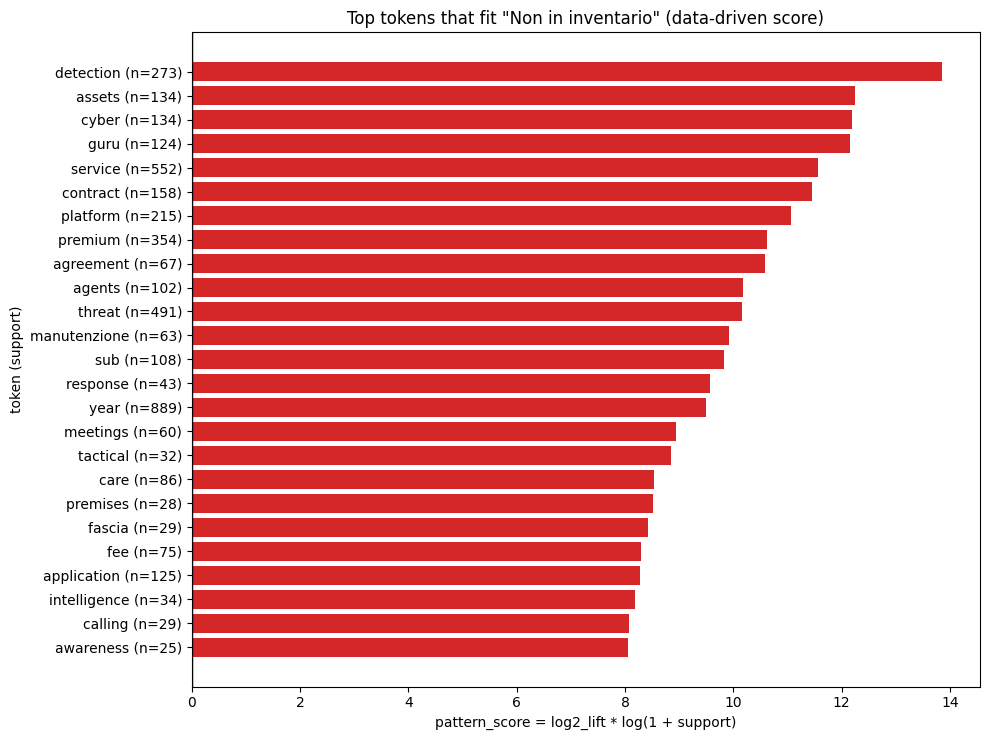

,token,support_total,support_non_inventario,p_non_inventario_given_token,log2_lift_non_inventario,excess_non_vs_expected,pattern_score
123,detection,273,262,0.959707,2.470118,214.715199,13.865091
31,assets,134,131,0.977612,2.496786,107.790611,12.247423
113,cyber,134,130,0.970149,2.485731,106.790611,12.193194
204,guru,124,123,0.991935,2.517771,101.522655,12.156587
400,service,552,340,0.615942,1.830319,244.391172,11.559120
102,contract,158,131,0.829114,2.259095,103.633705,11.451135
334,platform,215,155,0.720930,2.057384,117.761054,11.059012
353,premium,354,215,0.607345,1.810040,153.685643,10.628767
11,agreement,67,66,0.985075,2.507757,54.395305,10.581502
10,agents,102,81,0.794118,2.196877,63.333151,10.181930


In [ ]:
if inventory_col is None:
    print('inventory_col not found. Skip token/inventory analysis.')
else:
    import unicodedata
    from difflib import SequenceMatcher

    try:
        from wordfreq import zipf_frequency
        HAS_WORDFREQ = True
    except Exception:
        HAS_WORDFREQ = False

    tok_df = df[[desc_col, inventory_col]].dropna().copy()
    tok_df[desc_col] = tok_df[desc_col].astype(str).str.lower().str.strip()
    tok_df[inventory_col] = tok_df[inventory_col].astype(str).str.strip()

    token_pattern = r"[A-Za-z0-9]+"
    stopwords = {
        'di', 'da', 'per', 'con', 'del', 'della', 'delle', 'degli',
        'the', 'and', 'for', 'with', 'non', 'una', 'uno', 'all', 'dei',
        'dell', 'dalla', 'agli', 'dai', 'nelle', 'nella', 'srl'
    }

    def normalize_token_basic(t: str):
        t = str(t).strip().lower()
        t = unicodedata.normalize('NFKD', t)
        t = ''.join(ch for ch in t if not unicodedata.combining(ch))
        t = re.sub(r'[^a-z0-9]+', '', t)
        if len(t) < 3:
            return None
        if t in stopwords:
            return None
        return t

    tok_df['token'] = tok_df[desc_col].str.findall(token_pattern)
    tok_df = tok_df.explode('token')
    tok_df['token'] = tok_df['token'].apply(normalize_token_basic)
    tok_df = tok_df[tok_df['token'].notna()]

    if tok_df.empty:
        print('No tokens available after preprocessing.')
    else:
        # Generic typo/variant collapse (data-driven, no domain-specific rules).
        token_counts = tok_df['token'].value_counts()

        MIN_SUPPORT_FOR_CLUSTERING = 5
        SIMILARITY_THRESHOLD = 0.90
        MAX_LEN_DIFF = 2

        frequent_tokens = token_counts[token_counts >= MIN_SUPPORT_FOR_CLUSTERING].index.tolist()

        buckets = {}  # first char -> list of canonical tokens
        canon_map = {}

        for tok in frequent_tokens:
            first = tok[0]
            candidates = buckets.get(first, [])

            best = None
            best_score = 0.0
            for c in candidates:
                if abs(len(tok) - len(c)) > MAX_LEN_DIFF:
                    continue
                score = SequenceMatcher(None, tok, c).ratio()
                if score > best_score:
                    best_score = score
                    best = c

            if best is not None and best_score >= SIMILARITY_THRESHOLD:
                canon_map[tok] = best
            else:
                canon_map[tok] = tok
                buckets.setdefault(first, []).append(tok)

        # Infrequent tokens keep original form.
        tok_df['token_norm'] = tok_df['token'].map(canon_map).fillna(tok_df['token'])

        # Word-level sanity filter: keep only dictionary-like words.
        USE_WORD_DICTIONARY_FILTER = True
        MIN_WORD_ZIPF = 3.8
        TOKEN_BLACKLIST = {'soar'}

        def is_valid_word_token(t: str) -> bool:
            t = str(t)
            if t in TOKEN_BLACKLIST:
                return False
            if not re.fullmatch(r'[a-z]+', t):
                return False
            if not HAS_WORDFREQ or not USE_WORD_DICTIONARY_FILTER:
                return True
            score_en = zipf_frequency(t, 'en')
            score_it = zipf_frequency(t, 'it')
            return max(score_en, score_it) >= MIN_WORD_ZIPF

        before_word_filter = len(tok_df)
        tok_df = tok_df[tok_df['token_norm'].apply(is_valid_word_token)].copy()
        after_word_filter = len(tok_df)

        print(f'wordfreq filter active: {HAS_WORDFREQ and USE_WORD_DICTIONARY_FILTER}')
        print(f'tokens before word filter: {before_word_filter}, after: {after_word_filter}')

        if tok_df.empty:
            print('No tokens left after word-level filtering.')
        else:
            MIN_TOKEN_SUPPORT = 25
            TOP_SHOW = 25

            token_class = pd.crosstab(tok_df['token_norm'], tok_df[inventory_col])
            support_total = token_class.sum(axis=1)
            token_class = token_class.loc[support_total[support_total >= MIN_TOKEN_SUPPORT].index]
            support_total = token_class.sum(axis=1)

            if token_class.empty:
                print(f'No tokens with support >= {MIN_TOKEN_SUPPORT}.')
            else:
                p_class_given_token = token_class.div(support_total, axis=0)
                baseline = tok_df[inventory_col].value_counts(normalize=True).reindex(p_class_given_token.columns).fillna(0.0)

                eps = 1e-9
                log2_lift = np.log2((p_class_given_token + eps).div(baseline + eps, axis=1))

                def _norm(v):
                    return str(v).strip().lower()

                classes = list(p_class_given_token.columns)
                non_inv_class = next((c for c in classes if ('non' in _norm(c) and 'inventario' in _norm(c))), None)

                if non_inv_class is None:
                    print('Class "Non Inventario" not found. Available classes:')
                    print(classes)
                else:
                    support_non = token_class[non_inv_class]
                    expected_non = baseline[non_inv_class] * support_total

                    token_summary = pd.DataFrame({
                        'token': support_total.index,
                        'support_total': support_total.values,
                        'support_non_inventario': support_non.values,
                        'p_non_inventario_given_token': p_class_given_token[non_inv_class].values,
                        'log2_lift_non_inventario': log2_lift[non_inv_class].values,
                        'excess_non_vs_expected': (support_non - expected_non).values,
                    })

                    # Balance association strength + coverage.
                    token_summary['pattern_score'] = (
                        token_summary['log2_lift_non_inventario'] * np.log1p(token_summary['support_total'])
                    )

                    token_summary = token_summary.sort_values(
                        ['pattern_score', 'support_total'], ascending=[False, False]
                    )

                    top_pos = token_summary[token_summary['log2_lift_non_inventario'] > 0].head(TOP_SHOW).copy()
                    top_pos = top_pos.sort_values('pattern_score')
                    top_pos['label'] = top_pos['token'] + ' (n=' + top_pos['support_total'].astype(str) + ')'

                    fig_h = max(6, 0.30 * len(top_pos))
                    fig, ax = plt.subplots(figsize=(10, fig_h))
                    ax.barh(top_pos['label'], top_pos['pattern_score'], color='#d62728')
                    ax.axvline(0, color='black', linewidth=1)
                    ax.set_title(f'Top tokens that fit "{non_inv_class}" (data-driven score)')
                    ax.set_xlabel('pattern_score = log2_lift * log(1 + support)')
                    ax.set_ylabel('token (support)')
                    plt.tight_layout()
                    plt.show()

                    display(token_summary.head(TOP_SHOW))


## DU-4) Verify Data Quality
Check duplicates, conflicts, and plausibility issues.

Visualizations:
- issue-count dashboard,
- top conflicting codes.


,issue,count
2,description_with_multiple_targets,271
4,blank_description,61
0,duplicate_rows_all_cols,0
1,code_with_multiple_targets,0
3,blank_code,0
5,missing_target,0


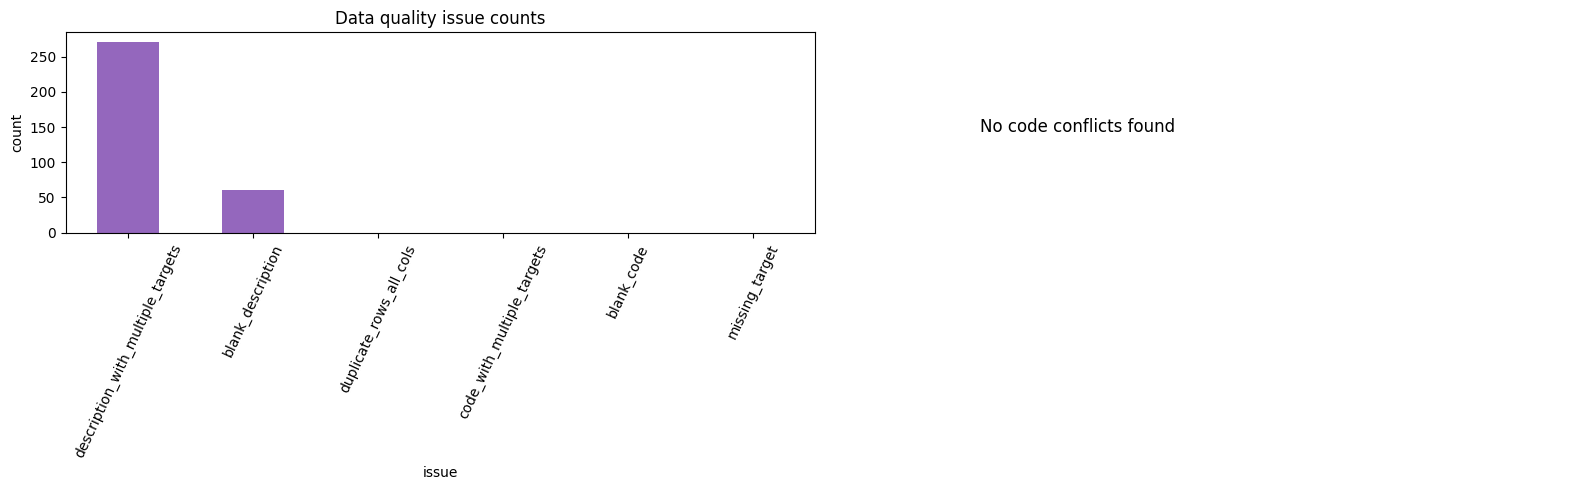

In [ ]:
duplicate_rows = int(df.duplicated(keep=False).sum())

code_target_n = (
    df[[code_col, target_col]]
    .dropna()
    .groupby(code_col)[target_col]
    .nunique(dropna=True)
)
code_conflicts = code_target_n[code_target_n > 1].sort_values(ascending=False)

desc_target_n = (
    df[[desc_col, target_col]]
    .dropna()
    .groupby(desc_col)[target_col]
    .nunique(dropna=True)
)
desc_conflicts = desc_target_n[desc_target_n > 1].sort_values(ascending=False)

blank_code = int(df[code_col].fillna('').astype(str).str.strip().eq('').sum())
blank_desc = int(df[desc_col].fillna('').astype(str).str.strip().eq('').sum())
missing_target = int(df[target_col].isna().sum())

issues_df = pd.DataFrame([
    {'issue': 'duplicate_rows_all_cols', 'count': duplicate_rows},
    {'issue': 'code_with_multiple_targets', 'count': int(len(code_conflicts))},
    {'issue': 'description_with_multiple_targets', 'count': int(len(desc_conflicts))},
    {'issue': 'blank_code', 'count': blank_code},
    {'issue': 'blank_description', 'count': blank_desc},
    {'issue': 'missing_target', 'count': missing_target},
]).sort_values('count', ascending=False)

display(issues_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
issues_df.plot(kind='bar', x='issue', y='count', ax=axes[0], color='#9467bd', legend=False)
axes[0].set_title('Data quality issue counts')
axes[0].set_xlabel('issue')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=65)

top_conf = code_conflicts.head(15).sort_values()
if top_conf.empty:
    axes[1].axis('off')
    axes[1].text(0.2, 0.5, 'No code conflicts found', fontsize=12)
else:
    top_conf.plot(kind='barh', ax=axes[1], color='#8c564b')
    axes[1].set_title('Top conflicting codes (# distinct targets)')
    axes[1].set_xlabel('distinct targets')
    axes[1].set_ylabel(code_col)

plt.tight_layout()
plt.show()

stage_sizes['quality_checked'] = len(df)


### DU-4.1) Description Conflicts: Which LOBs are mixed?
Visualize descriptions that map to multiple LOB values (`description_with_multiple_targets`).


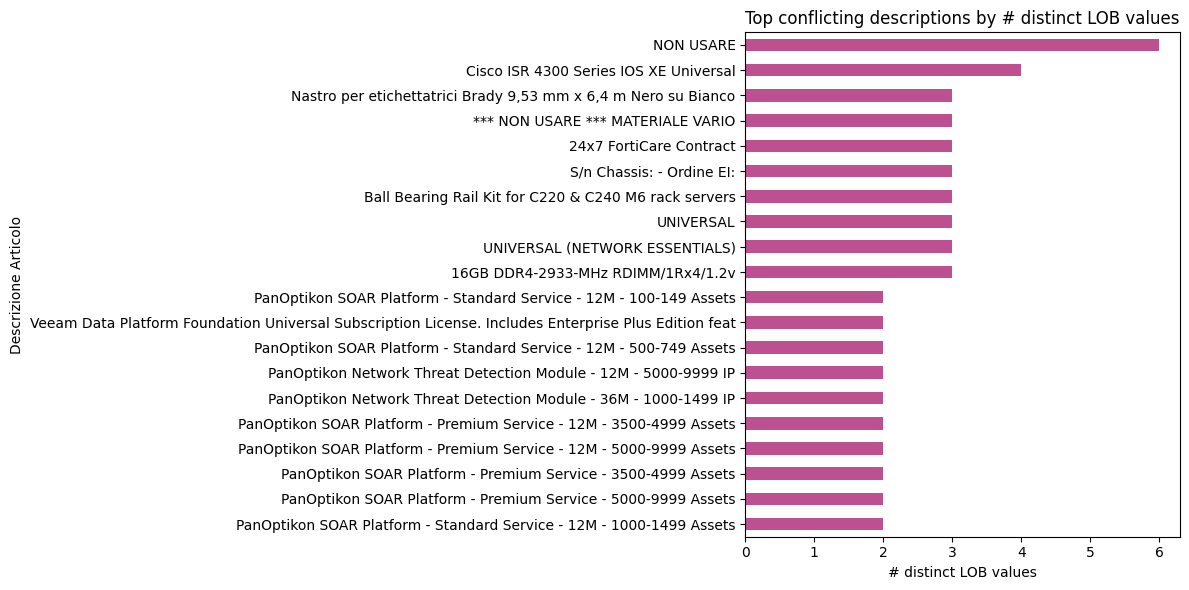

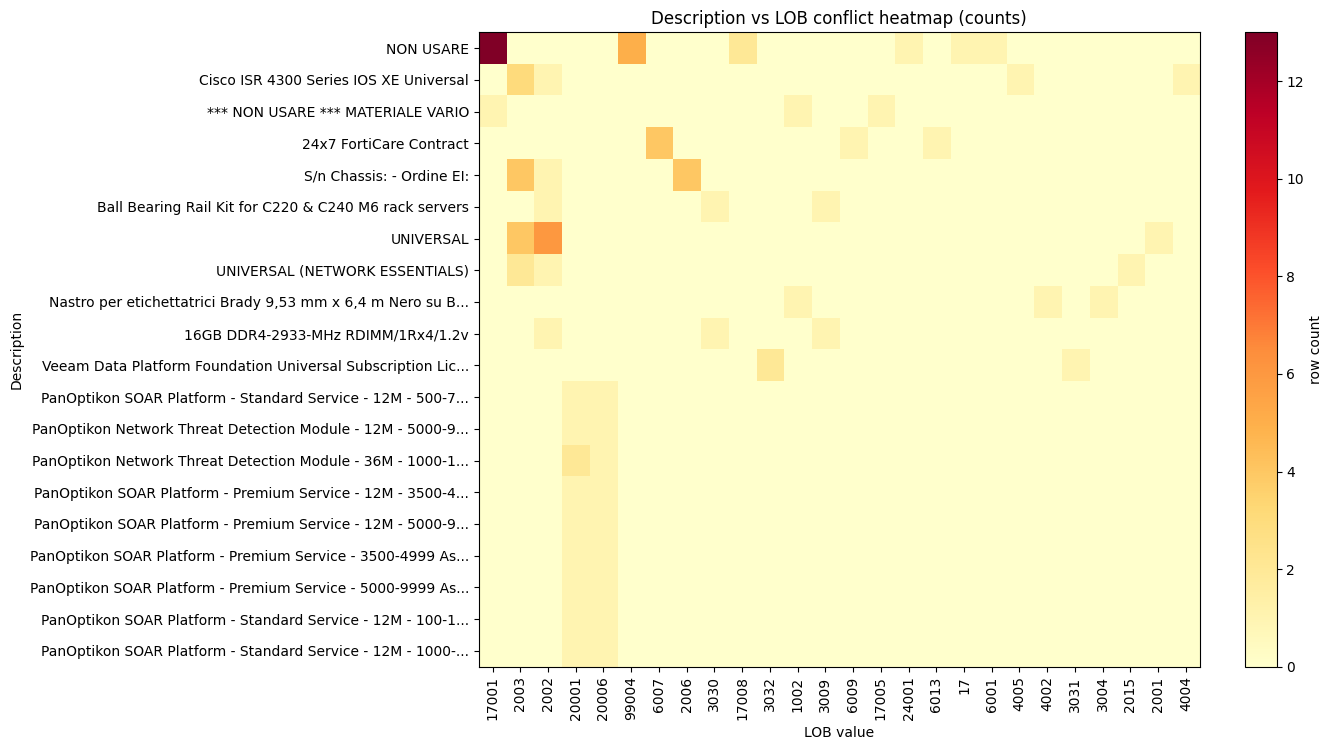

,Descrizione Articolo,lob_values,lob_nunique
5,NON USARE,"17, 6001, 17001, 17008, 24001, 99004",6
4,Cisco ISR 4300 Series IOS XE Universal,"2002, 2003, 4004, 4005",4
0,*** NON USARE *** MATERIALE VARIO,"1002, 17001, 17005",3
1,16GB DDR4-2933-MHz RDIMM/1Rx4/1.2v,"2002, 3009, 3030",3
2,24x7 FortiCare Contract,"6007, 6009, 6013",3
3,Ball Bearing Rail Kit for C220 & C240 M6 rack ...,"2002, 3009, 3030",3
6,"Nastro per etichettatrici Brady 9,53 mm x 6,4 ...","1002, 3004, 4002",3
16,S/n Chassis: - Ordine EI:,"2002, 2003, 2006",3
17,UNIVERSAL,"2001, 2002, 2003",3
18,UNIVERSAL (NETWORK ESSENTIALS),"2002, 2003, 2015",3


In [ ]:
# Top conflicting descriptions by number of distinct LOB targets.
TOP_CONFLICT_DESC = 20

conf_desc_counts = desc_conflicts.head(TOP_CONFLICT_DESC).copy()

if conf_desc_counts.empty:
    print('No description conflicts found.')
else:
    # 1) Bar chart: how many different LOB values per description
    fig, ax = plt.subplots(figsize=(12, 6))
    conf_desc_counts.sort_values().plot(kind='barh', ax=ax, color='#bc5090')
    ax.set_title('Top conflicting descriptions by # distinct LOB values')
    ax.set_xlabel('# distinct LOB values')
    ax.set_ylabel(desc_col)
    plt.tight_layout()
    plt.show()

    # 2) Heatmap: description x LOB (counts)
    conflict_rows = df[df[desc_col].isin(conf_desc_counts.index)][[desc_col, target_col]].dropna().copy()
    conflict_rows[target_col] = pd.to_numeric(conflict_rows[target_col], errors='coerce').astype('Int64')

    conflict_matrix = (
        conflict_rows.groupby([desc_col, target_col]).size().reset_index(name='count')
        .pivot(index=desc_col, columns=target_col, values='count')
        .fillna(0)
    )

    row_order = conf_desc_counts.index
    row_order = [r for r in row_order if r in conflict_matrix.index]
    conflict_matrix = conflict_matrix.loc[row_order]
    conflict_matrix = conflict_matrix[conflict_matrix.sum(axis=0).sort_values(ascending=False).index]

    # Short labels to keep plot readable.
    def short_label(x, max_len=60):
        x = str(x)
        return x if len(x) <= max_len else x[: max_len - 3] + '...'

    y_labels = [short_label(x) for x in conflict_matrix.index]
    x_labels = [str(x) for x in conflict_matrix.columns]

    fig_h = max(6, 0.38 * len(conflict_matrix))
    fig, ax = plt.subplots(figsize=(14, fig_h))
    im = ax.imshow(conflict_matrix.values, aspect='auto', cmap='YlOrRd')
    ax.set_title('Description vs LOB conflict heatmap (counts)')
    ax.set_xlabel('LOB value')
    ax.set_ylabel('Description')
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=90)
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)
    fig.colorbar(im, ax=ax, label='row count')
    plt.tight_layout()
    plt.show()

    # 3) Table: explicit list of LOB values per description.
    desc_lob_list = (
        conflict_rows.groupby(desc_col)[target_col]
        .apply(lambda s: ', '.join(str(v) for v in sorted(pd.Series(s).dropna().unique().tolist())))
        .reset_index(name='lob_values')
    )
    desc_lob_list['lob_nunique'] = desc_lob_list['lob_values'].str.count(',') + 1
    desc_lob_list = desc_lob_list.sort_values(['lob_nunique', desc_col], ascending=[False, True])

    display(desc_lob_list.head(TOP_CONFLICT_DESC))


## DP-1) Select Data
Define final analysis columns and document excluded fields.

Visualization:
- before/after selected feature count.


,column,selected,reason
0,Codice Articolo,True,kept_for_pipeline
1,Lob Associata,True,kept_for_pipeline
2,Nome LOB,False,excluded_at_selection_step
3,Inventario,True,kept_for_pipeline
4,Descrizione Articolo,True,kept_for_pipeline


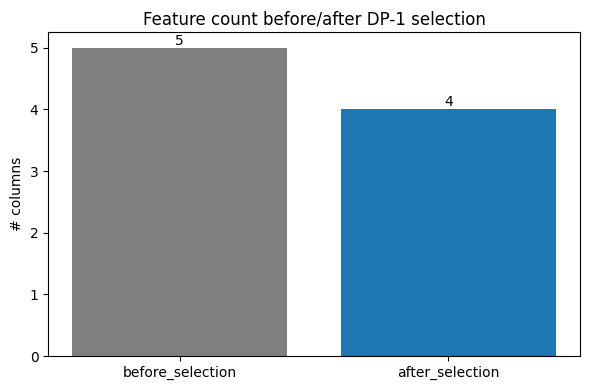

In [ ]:
selected_cols = []
for c in [code_col, desc_col, inventory_col, target_col]:
    if c and c not in selected_cols:
        selected_cols.append(c)

dropped_cols = [c for c in df.columns if c not in selected_cols]

selection_df = pd.DataFrame({
    'column': df.columns,
    'selected': df.columns.isin(selected_cols),
    'reason': [
        'kept_for_pipeline' if c in selected_cols else 'excluded_at_selection_step'
        for c in df.columns
    ],
})

display(selection_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['before_selection', 'after_selection'], [len(df.columns), len(selected_cols)], color=['#7f7f7f', '#1f77b4'])
ax.set_title('Feature count before/after DP-1 selection')
ax.set_ylabel('# columns')
for i, v in enumerate([len(df.columns), len(selected_cols)]):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()

df_sel = df[selected_cols].copy()
stage_sizes['selected'] = len(df_sel)


## DP-2) Cleanse Data
Two-stage cleansing:

### Stage A: Source-driven pre-pruning (applied first)
1. Exclude source LOB codes: `78*`, `01003`, `01009`, `01015`, `01011`
2. Exclude rows where services are marked as `Inventario` (treated as source errors)
3. Exclude rows where target LOB is not present in Excel sheet `LOB` (`Code` catalog)

### Stage B: Additional pruning rules (applied after Stage A)
1. `Assistenza` class in `Inventario` -> pruned
2. Descriptions matching `non usare` (or similar forms) -> pruned
3. `blank_description` -> pruned
4. `description_with_multiple_targets` conflicts -> pruned

Also applies safe LOB relabeling from `grouping_lob_autofix_safe.csv`.


rows before DP-2: 22655
rows after Stage A pre-pruning: 21272
rows after Stage B pruning: 20499
duplicates removed after pruning: 0
target relabelled rows (kept rows): 49
outlier rows by token count (IQR): 431

Stage A (source pre-pruning) summary:


,rule,count
0,"Source LOB excludes (78*, 01003, 01009, 01015,...",1161
1,Service marked as Inventario - prepruned,222
2,LOB not found in sheet LOB - prepruned,0
3,Total prepruned (union),1383


Stage B (additional pruning) summary:


,rule,count
0,Assistenza - pruned,11
1,Non usare - pruned,31
2,Blank description - pruned,62
3,description_with_multiple_targets - pruned,701
4,Total pruned (union),773
5,Rows kept after Stage B,20499


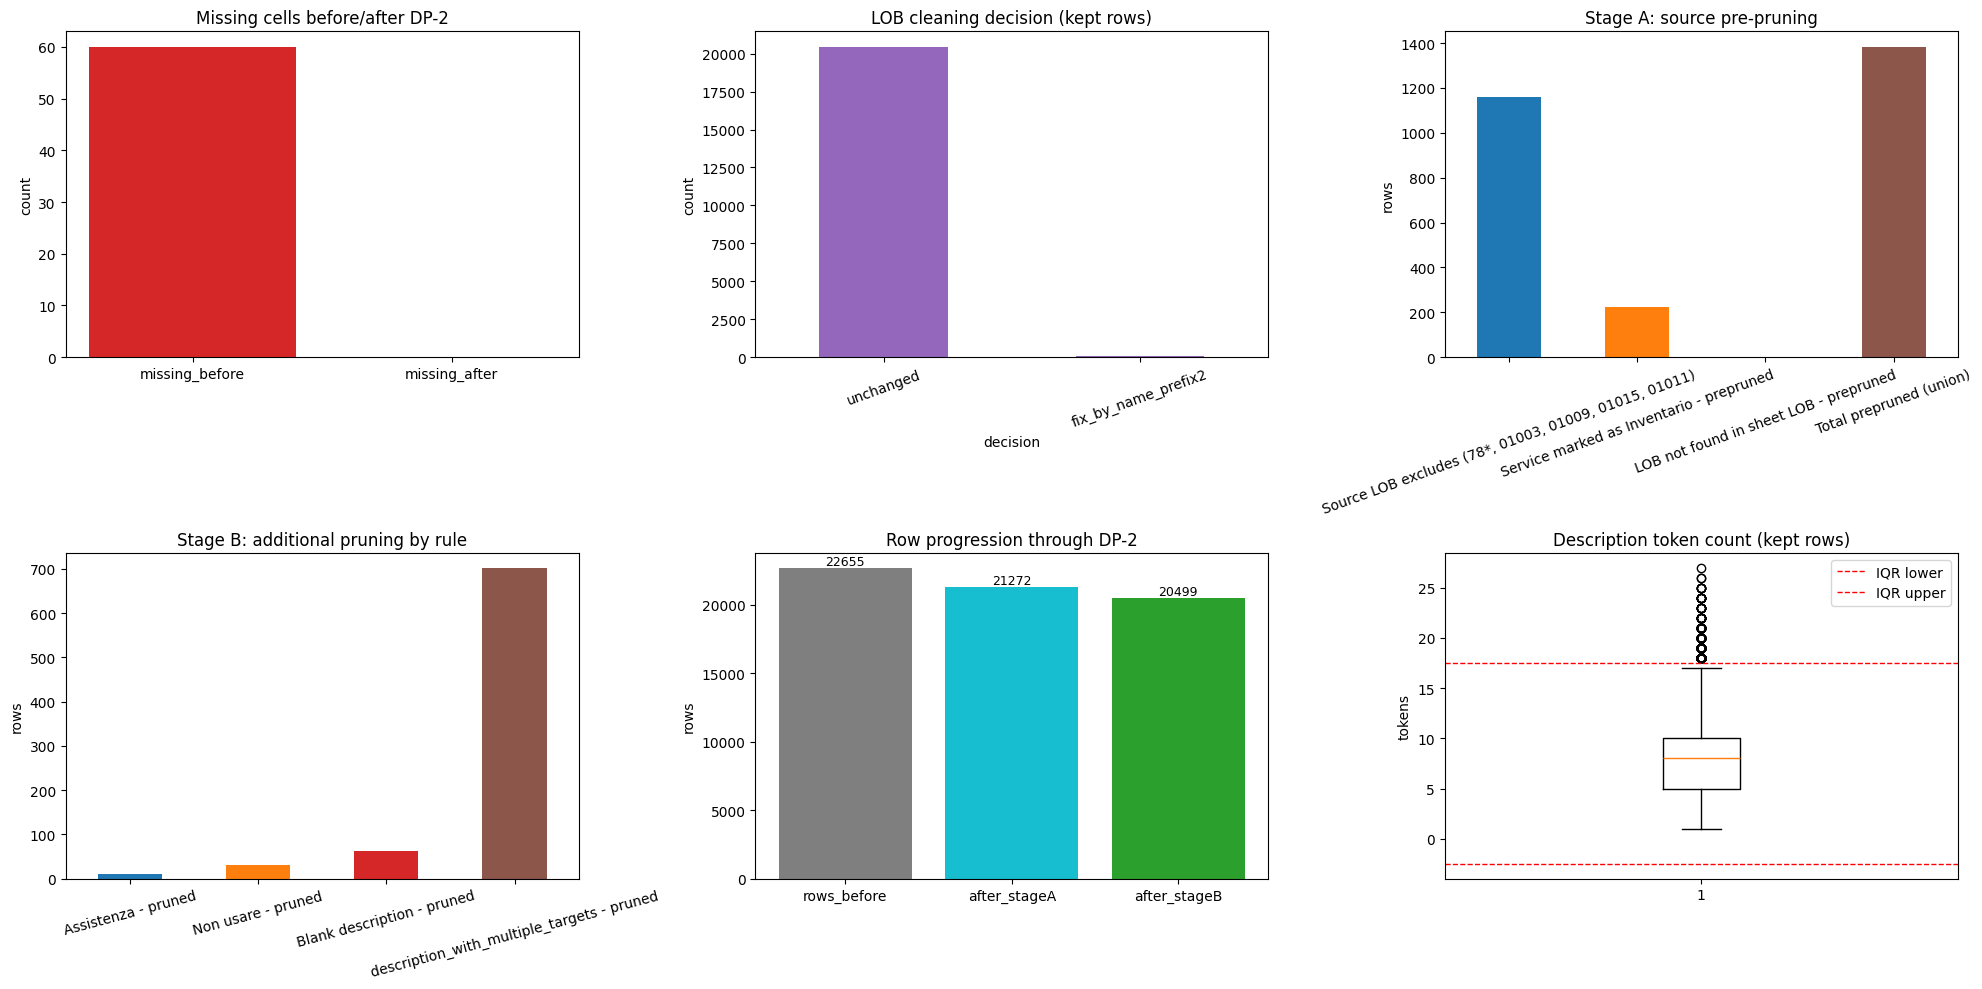

In [ ]:
df_clean = df_sel.copy()

# Ensure raw target is numeric for stable joins/comparisons.
df_clean[target_col_raw] = pd.to_numeric(df_clean[target_col_raw], errors='coerce').astype('Int64')

missing_before = int(df_clean.isna().sum().sum())
rows_before = len(df_clean)

# Normalize text-like columns only.
text_cols = [c for c in df_clean.columns if df_clean[c].dtype == 'object']
for c in text_cols:
    x = df_clean[c].astype(str)
    x = x.str.replace(r'\s+', ' ', regex=True).str.strip()
    x = x.replace({'nan': np.nan})
    df_clean[c] = x

# Mandatory fields for training rows.
df_clean = df_clean[df_clean[code_col].notna()]
df_clean = df_clean[df_clean[target_col_raw].notna()]

# Load safe relabeling rules (if available) and create cleaned target.
DQ_DIR_CANDIDATES = [
    NOTEBOOK_DIR / 'data_quality',
    DATA_PATH.parent / 'Classification pattern' / 'data_quality',
    Path('C:/Users/sveta/Documents/vem-product/Classification pattern/data_quality'),
]
DATA_QUALITY_DIR = next((p for p in DQ_DIR_CANDIDATES if p.exists()), None)
auto_fix_path = (DATA_QUALITY_DIR / 'grouping_lob_autofix_safe.csv') if DATA_QUALITY_DIR else None

if auto_fix_path and auto_fix_path.exists():
    auto_fix_df = pd.read_csv(auto_fix_path)
    map_df = auto_fix_df[['Codice Articolo', 'current_lob', 'suggested_lob']].copy()
    map_df['Codice Articolo'] = map_df['Codice Articolo'].astype(str).str.strip()
    map_df['current_lob'] = pd.to_numeric(map_df['current_lob'], errors='coerce').astype('Int64')
    map_df['suggested_lob'] = pd.to_numeric(map_df['suggested_lob'], errors='coerce').astype('Int64')
    map_df = map_df.dropna(subset=['Codice Articolo', 'current_lob', 'suggested_lob']).drop_duplicates(['Codice Articolo', 'current_lob'])

    merge_df = df_clean[[code_col, target_col_raw]].copy()
    merge_df[code_col] = merge_df[code_col].astype(str).str.strip()

    merge_df = merge_df.merge(
        map_df,
        how='left',
        left_on=[code_col, target_col_raw],
        right_on=['Codice Articolo', 'current_lob']
    )

    df_clean[target_col_clean] = merge_df['suggested_lob'].fillna(df_clean[target_col_raw]).astype('Int64')
    df_clean['LOB Cleaning Decision'] = np.where(
        df_clean[target_col_clean] != df_clean[target_col_raw],
        'fix_by_name_prefix2',
        'unchanged'
    )
else:
    df_clean[target_col_clean] = df_clean[target_col_raw]
    df_clean['LOB Cleaning Decision'] = 'unchanged'

# From this point onward, modeling target is cleaned target.
target_col = target_col_clean

# ------------------------------------------------------------------
# Stage A: Source-driven pre-pruning (must happen first)
# ------------------------------------------------------------------

inv_norm = (
    df_clean[inventory_col]
    .fillna('')
    .astype(str)
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

desc_norm = (
    df_clean[desc_col]
    .fillna('')
    .astype(str)
    .str.lower()
    .str.replace(r'[^a-z0-9]+', ' ', regex=True)
    .str.strip()
)

lob_num_raw = pd.to_numeric(df_clean[target_col_raw], errors='coerce').astype('Int64')
lob_code5_raw = lob_num_raw.astype(str).str.replace('<NA>', '', regex=False).str.zfill(5)

lob_num_model = pd.to_numeric(df_clean[target_col], errors='coerce').astype('Int64')
lob_code5_model = lob_num_model.astype(str).str.replace('<NA>', '', regex=False).str.zfill(5)

# Source excluded LOBs
SOURCE_EXCLUDED_LOB_EXACT = {'01003', '01009', '01015', '01011'}
SOURCE_EXCLUDED_LOB_PREFIX = ('78',)

mask_source_lob = lob_code5_raw.isin(SOURCE_EXCLUDED_LOB_EXACT)
for pref in SOURCE_EXCLUDED_LOB_PREFIX:
    mask_source_lob = mask_source_lob | lob_code5_raw.str.startswith(pref, na=False)

# Services marked as inventory -> source errors
# Data-driven reference: descriptions already appearing in non-inventario/assistenza
service_desc_ref = set(desc_norm[(inv_norm.isin(['non in inventario', 'assistenza'])) & (desc_norm != '')].unique())
mask_service_marked_inventory = inv_norm.eq('inventario') & desc_norm.isin(service_desc_ref) & desc_norm.ne('')

# LOB code must exist in sheet `LOB` (`Code` catalog).
mask_lob_not_in_catalog = pd.Series(False, index=df_clean.index)
valid_lob_catalog_codes5 = set()
try:
    lob_catalog = pd.read_excel(DATA_PATH, sheet_name='LOB')
    lob_code_col = 'Code' if 'Code' in lob_catalog.columns else lob_catalog.columns[0]
    lob_code_digits = (
        lob_catalog[lob_code_col]
        .astype(str)
        .str.strip()
        .str.replace(r'[^0-9]', '', regex=True)
    )
    valid_lob_catalog_codes5 = set(lob_code_digits[lob_code_digits.ne('')].str.zfill(5).tolist())
    if len(valid_lob_catalog_codes5) > 0:
        mask_lob_not_in_catalog = ~lob_code5_model.isin(valid_lob_catalog_codes5)
except Exception as e:
    print(f'LOB catalog validation skipped (sheet `LOB` not readable): {e}')

mask_preprune = mask_source_lob | mask_service_marked_inventory | mask_lob_not_in_catalog

preprune_counts = pd.Series({
    'Source LOB excludes (78*, 01003, 01009, 01015, 01011)': int(mask_source_lob.sum()),
    'Service marked as Inventario - prepruned': int(mask_service_marked_inventory.sum()),
    'LOB not found in sheet LOB - prepruned': int(mask_lob_not_in_catalog.sum()),
    'Total prepruned (union)': int(mask_preprune.sum()),
})

rows_after_preprune = int((~mask_preprune).sum())
df_clean = df_clean.loc[~mask_preprune].reset_index(drop=True).copy()

# ------------------------------------------------------------------
# Stage B: Additional pruning rules (after pre-pruning)
# ------------------------------------------------------------------

inv_norm_b = (
    df_clean[inventory_col]
    .fillna('')
    .astype(str)
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

desc_norm_b = (
    df_clean[desc_col]
    .fillna('')
    .astype(str)
    .str.lower()
    .str.replace(r'[^a-z0-9]+', ' ', regex=True)
    .str.strip()
)

mask_blank_desc = desc_norm_b.eq('')
mask_non_usare = (
    desc_norm_b.str.contains(r'\bnon\s*usare\b', regex=True, na=False)
    | desc_norm_b.str.contains(r'\bnonusare\b', regex=True, na=False)
)
mask_assistenza = inv_norm_b.str.contains(r'\bassistenza\b', regex=True, na=False)

conf_desc_nunique = (
    pd.DataFrame({'desc_norm': desc_norm_b, 'target': df_clean[target_col]})
    .loc[~mask_blank_desc]
    .groupby('desc_norm')['target']
    .nunique(dropna=True)
)
conf_desc_set = set(conf_desc_nunique[conf_desc_nunique > 1].index)
mask_desc_multi_target = desc_norm_b.isin(conf_desc_set)

mask_prune = mask_assistenza | mask_non_usare | mask_blank_desc | mask_desc_multi_target

rows_pruned_total = int(mask_prune.sum())
df_clean = df_clean.loc[~mask_prune].reset_index(drop=True).copy()

duplicates_removed = int(df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True).copy()

missing_after = int(df_clean.isna().sum().sum())
rows_after = len(df_clean)

desc_tokens = df_clean[desc_col].astype(str).str.findall(r'[A-Za-z0-9]+').str.len()
df_clean['desc_token_count'] = desc_tokens

q1 = float(desc_tokens.quantile(0.25)) if len(desc_tokens) else 0.0
q3 = float(desc_tokens.quantile(0.75)) if len(desc_tokens) else 0.0
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (desc_tokens < lower) | (desc_tokens > upper) if len(desc_tokens) else pd.Series([], dtype=bool)
df_clean['desc_token_outlier'] = outlier_mask.astype(int) if len(desc_tokens) else 0

relabelled_rows = int((df_clean[target_col_clean] != df_clean[target_col_raw]).sum()) if len(df_clean) else 0

prune_counts = pd.Series({
    'Assistenza - pruned': int(mask_assistenza.sum()),
    'Non usare - pruned': int(mask_non_usare.sum()),
    'Blank description - pruned': int(mask_blank_desc.sum()),
    'description_with_multiple_targets - pruned': int(mask_desc_multi_target.sum()),
    'Total pruned (union)': rows_pruned_total,
    'Rows kept after Stage B': rows_after,
})

print(f'rows before DP-2: {rows_before}')
print(f'rows after Stage A pre-pruning: {rows_after_preprune}')
print(f'rows after Stage B pruning: {rows_after}')
print(f'duplicates removed after pruning: {duplicates_removed}')
print(f'target relabelled rows (kept rows): {relabelled_rows}')
print(f'outlier rows by token count (IQR): {int(outlier_mask.sum()) if len(desc_tokens) else 0}')

print('\nStage A (source pre-pruning) summary:')
display(preprune_counts.rename_axis('rule').reset_index(name='count'))

print('Stage B (additional pruning) summary:')
display(prune_counts.rename_axis('rule').reset_index(name='count'))

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

axes[0, 0].bar(['missing_before', 'missing_after'], [missing_before, missing_after], color=['#d62728', '#2ca02c'])
axes[0, 0].set_title('Missing cells before/after DP-2')
axes[0, 0].set_ylabel('count')

df_clean['LOB Cleaning Decision'].value_counts().plot(kind='bar', ax=axes[0, 1], color='#9467bd')
axes[0, 1].set_title('LOB cleaning decision (kept rows)')
axes[0, 1].set_xlabel('decision')
axes[0, 1].set_ylabel('count')
axes[0, 1].tick_params(axis='x', rotation=20)

preprune_counts.plot(kind='bar', ax=axes[0, 2], color=['#1f77b4', '#ff7f0e', '#9467bd', '#8c564b'])
axes[0, 2].set_title('Stage A: source pre-pruning')
axes[0, 2].set_ylabel('rows')
axes[0, 2].tick_params(axis='x', rotation=20)

prune_plot = prune_counts[['Assistenza - pruned', 'Non usare - pruned', 'Blank description - pruned', 'description_with_multiple_targets - pruned']]
prune_plot.plot(kind='bar', ax=axes[1, 0], color=['#1f77b4', '#ff7f0e', '#d62728', '#8c564b'])
axes[1, 0].set_title('Stage B: additional pruning by rule')
axes[1, 0].set_ylabel('rows')
axes[1, 0].tick_params(axis='x', rotation=15)

axes[1, 1].bar(['rows_before', 'after_stageA', 'after_stageB'], [rows_before, rows_after_preprune, rows_after], color=['#7f7f7f', '#17becf', '#2ca02c'])
axes[1, 1].set_title('Row progression through DP-2')
axes[1, 1].set_ylabel('rows')
for i, v in enumerate([rows_before, rows_after_preprune, rows_after]):
    axes[1, 1].text(i, v, str(int(v)), ha='center', va='bottom', fontsize=9)

if len(desc_tokens):
    axes[1, 2].boxplot(desc_tokens.values, vert=True)
    axes[1, 2].axhline(lower, color='red', linestyle='--', linewidth=1, label='IQR lower')
    axes[1, 2].axhline(upper, color='red', linestyle='--', linewidth=1, label='IQR upper')
    axes[1, 2].set_title('Description token count (kept rows)')
    axes[1, 2].set_ylabel('tokens')
    axes[1, 2].legend(loc='upper right')
else:
    axes[1, 2].axis('off')
    axes[1, 2].text(0.2, 0.5, 'No rows left after pruning', fontsize=12)

plt.tight_layout()
plt.show()

stage_sizes['cleaned'] = len(df_clean)


## DP-3) Construct Features
Build features in **two steps**:
1) data-driven pattern discovery from `description` <-> `LOB` matrices;
2) business-rule mapping to create `brand_vendor` and `product_family`.

Derived columns from description:
- `duration_months`
- `brand_vendor`
- `product_family`
- `capacity_unit`

Visualizations:
- token/LOB and bigram/LOB association matrices,
- feature signal ranking,
- coverage + top-category distributions,
- unknown-brand diagnostics,
- token-to-label matrices for `brand_vendor` and `product_family`.



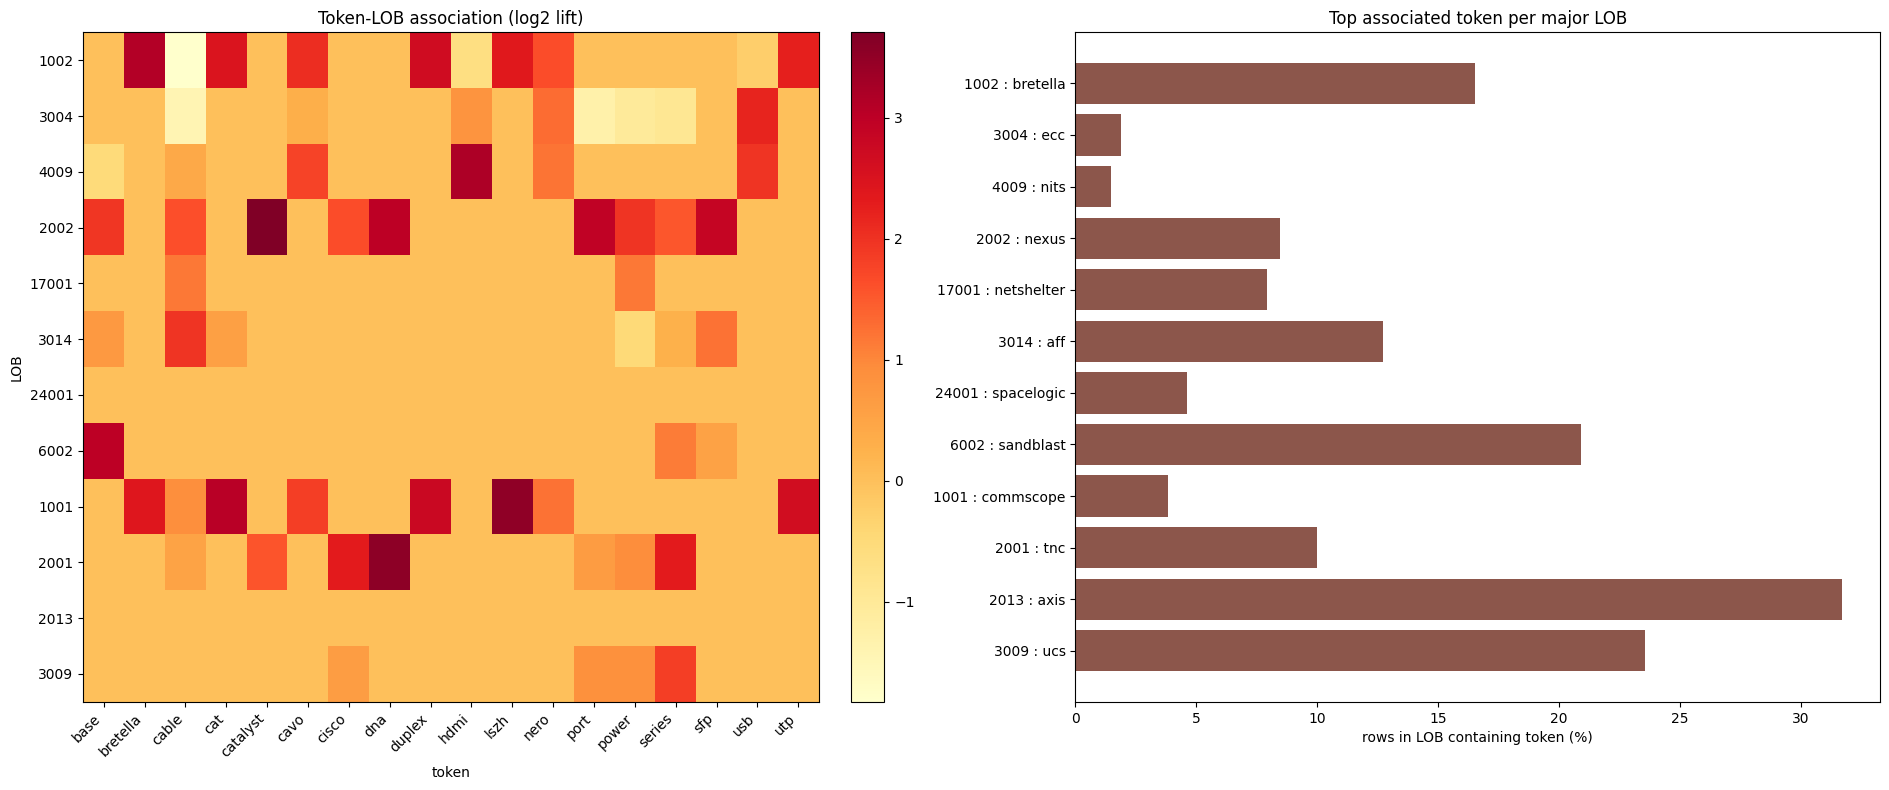

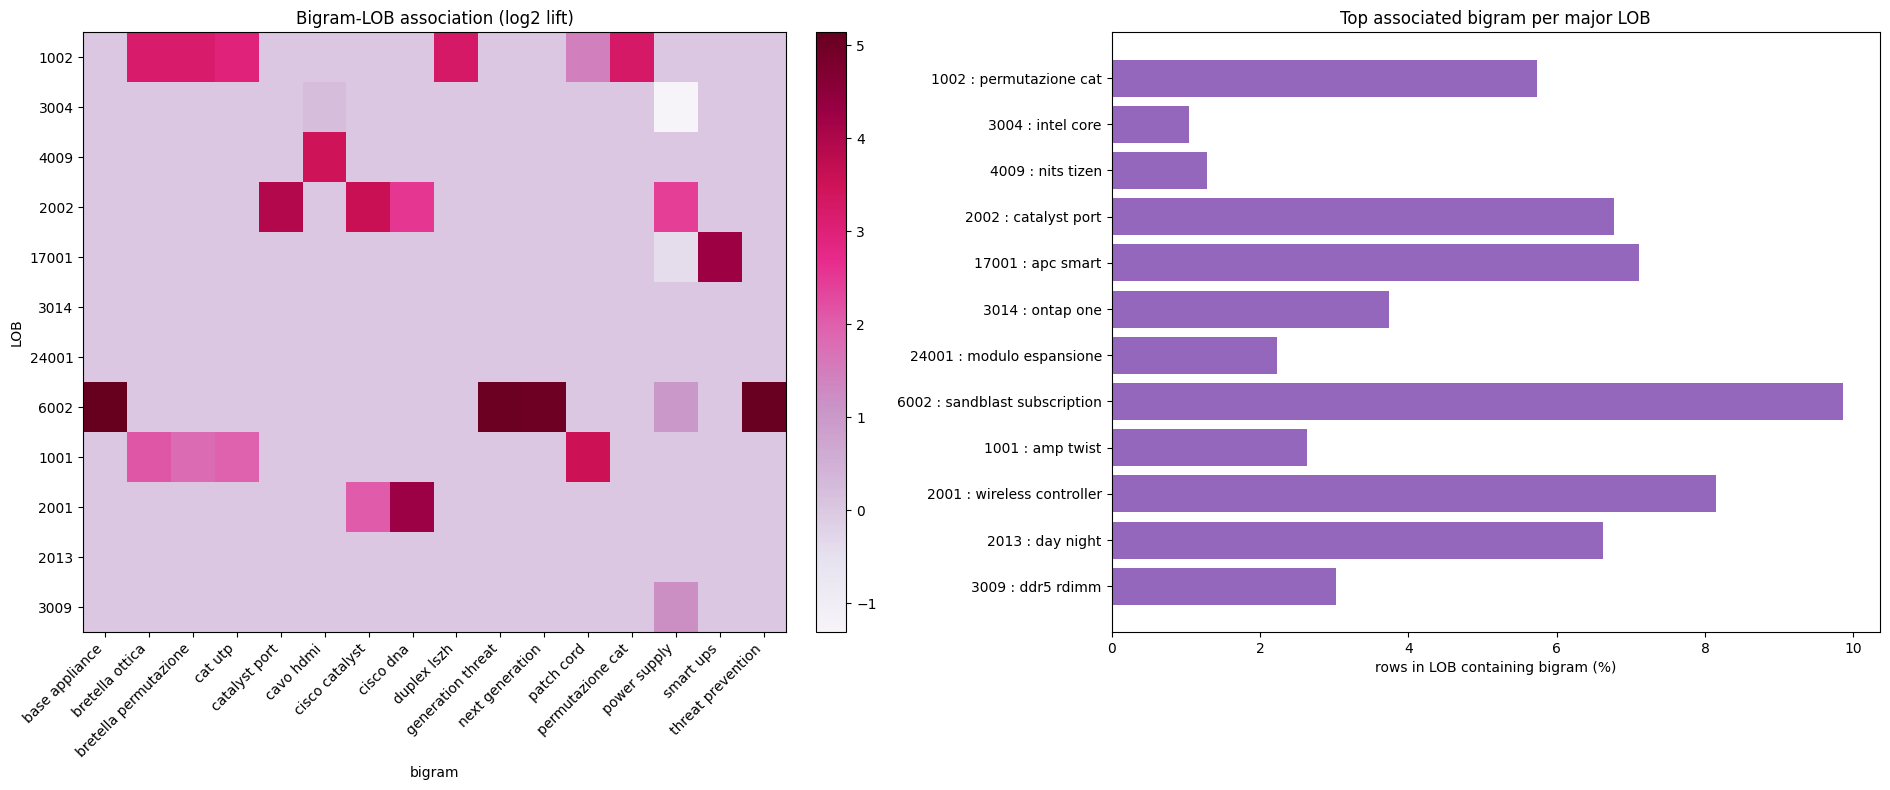

New feature coverage (non-default share):


,feature,filled_ratio,distinct_values
0,duration_months,0.097956,31
1,brand_vendor,0.327333,54
2,product_family,0.555100,25
3,capacity_unit,0.145178,13


,Descrizione Articolo,duration_months,brand_vendor,product_family,capacity_unit
0,PATCH CORD UTP 2/RJ45 CAT5E MT2,NaN,unknown,cabling_copper,none
1,cab - cf54/150ez passerella a filo 3m,NaN,unknown,other,none
2,QUARKZMAN 30pz Ultra Sottile Telefono Leva Ape...,NaN,unknown,other,none
3,adattatore vga-hdmi,NaN,unknown,other,none
4,ERICSSON DT290/292 BATTERIA CORDLESS,NaN,ericsson,other,none
5,FOTOCELLULA CAME DA ESTERNO COPPIA RICEVITORE/...,NaN,unknown,other,none
6,CUSTODIA MORBIDA DCC-80,NaN,unknown,other,none
7,E350 E352DN 3 ANNI TOTALI (1+2),36.0,unknown,other,none
8,CELLULARE NOKIA E52 NAVY,NaN,nokia,other,none
9,Presa mult. 3P BIANCA,NaN,unknown,other,none


First-token vs brand_vendor check:


,metric,value,note
0,first_token_brand_precision_proxy,0.951695,among rows where both first-token and regex br...
1,first_token_brand_recall_proxy,0.669449,share of regex-known brands recovered by first...
2,rows_with_known_brand_vendor,6710.000000,brand_vendor != unknown
3,rows_with_known_first_token_brand,4736.000000,first token mapped to known brand alias


,status,count
0,neither_detected,13773
1,first_token_matches_brand,4492
2,brand_only_not_in_first_token,1990
3,first_token_conflicts_brand,228
4,first_token_only,16


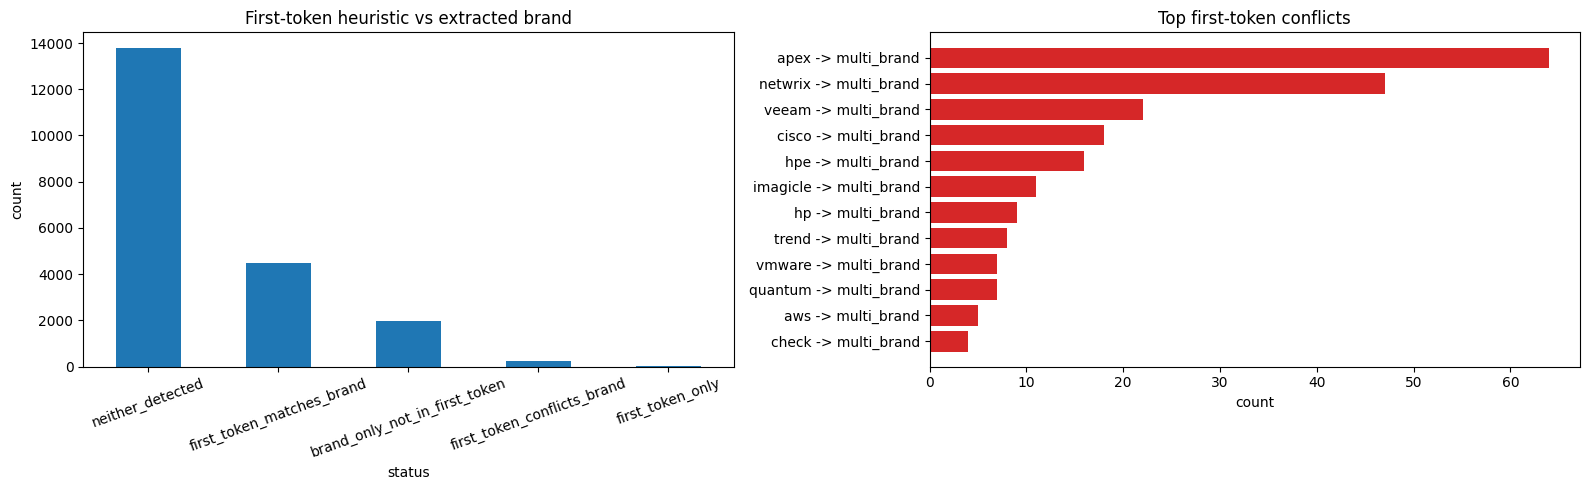

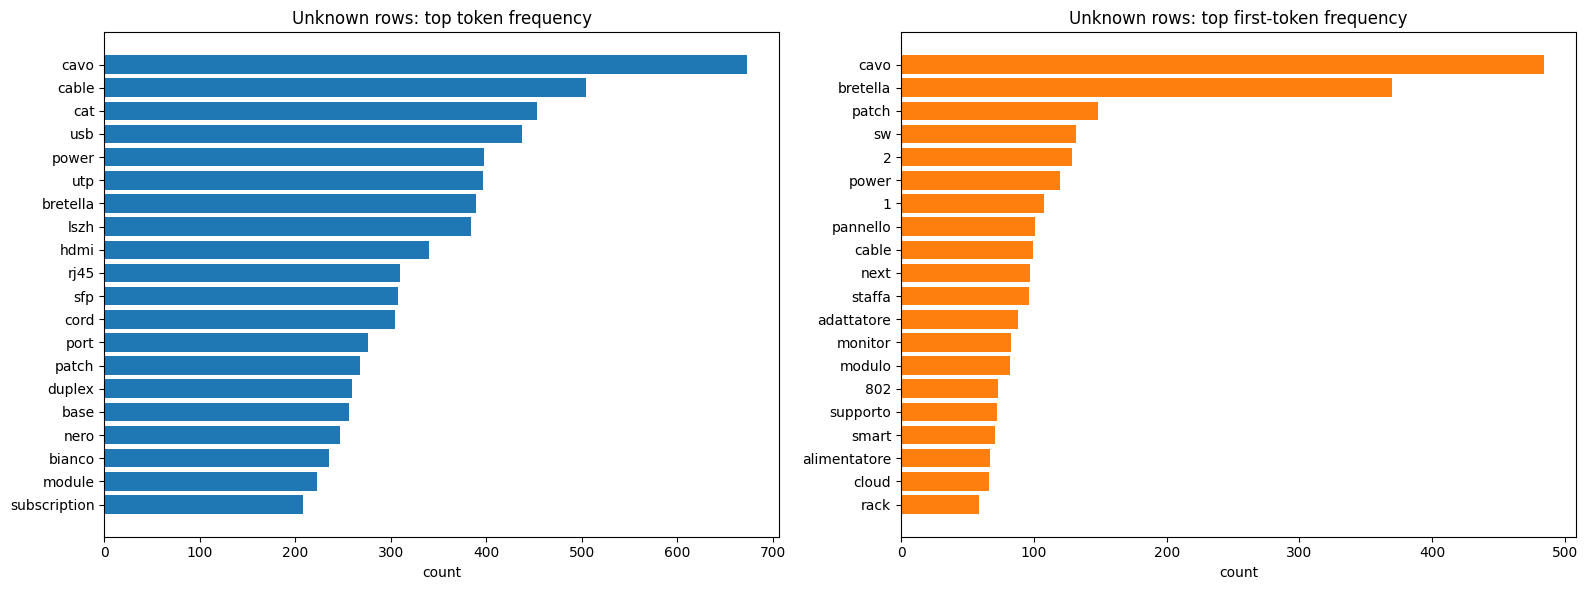

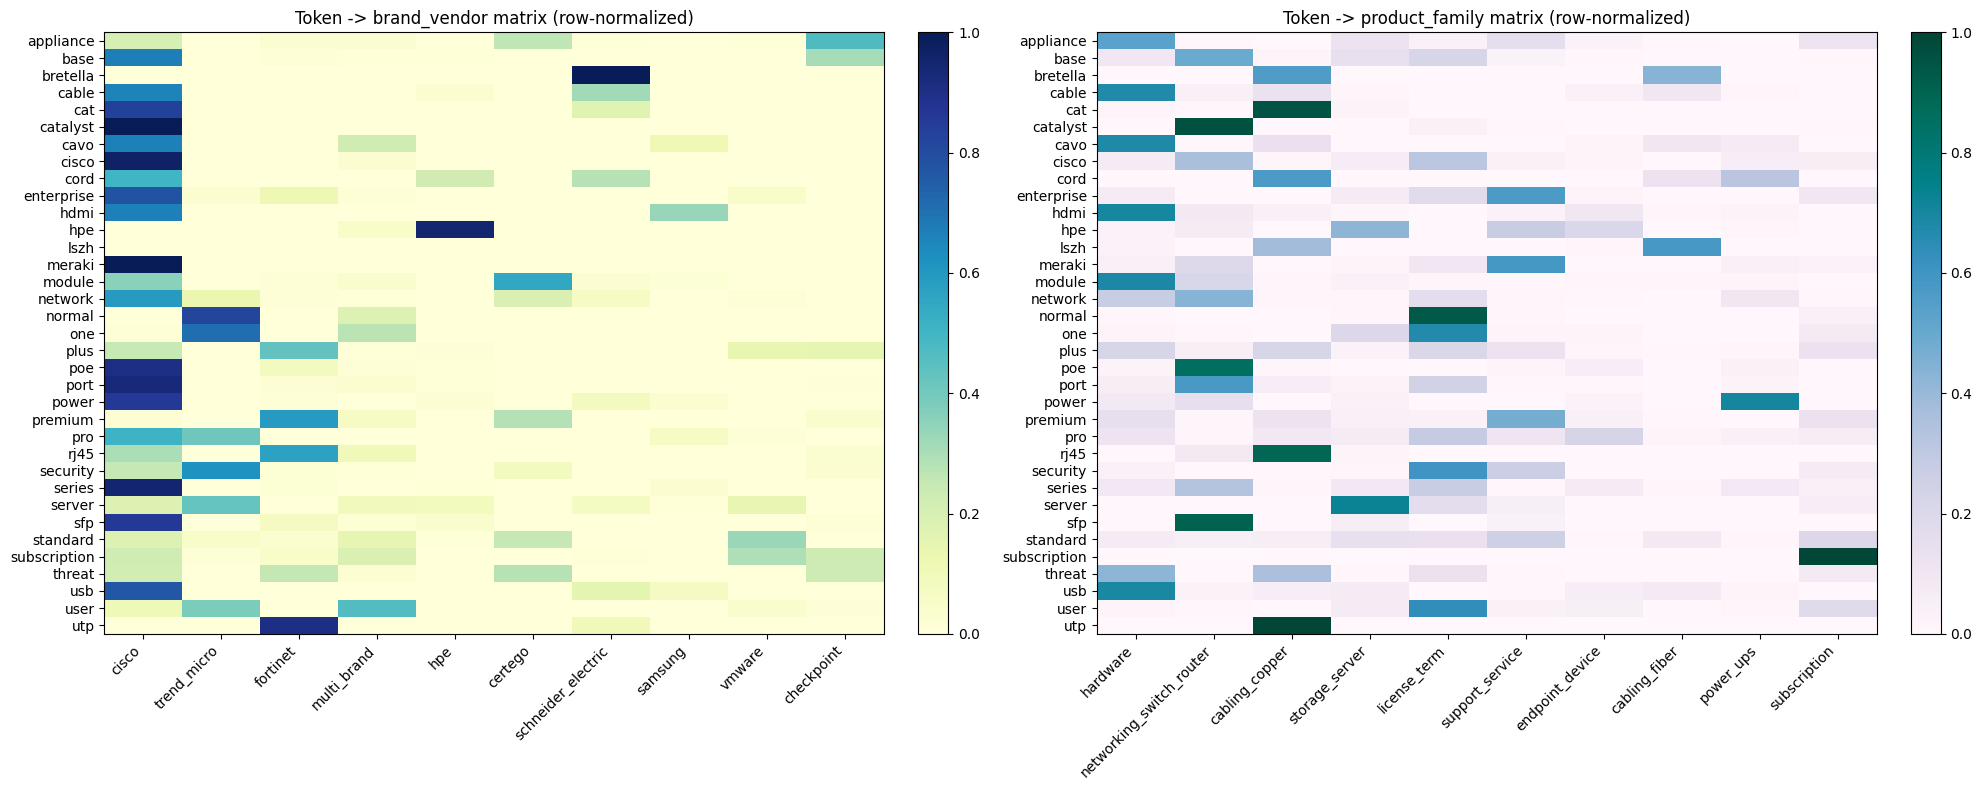

,feature,score,score_type
0,code_prefix,0.680228,weighted_purity
1,first_token,0.673789,weighted_purity
6,code_len,0.359126,between_variance_ratio
10,duration_months,0.327066,between_variance_ratio
7,desc_char_len,0.267793,between_variance_ratio
2,brand_vendor,0.266257,weighted_purity
3,product_family,0.221816,weighted_purity
9,has_digit_in_code,0.205339,between_variance_ratio
8,desc_token_count,0.162103,between_variance_ratio
4,capacity_unit,0.153764,weighted_purity


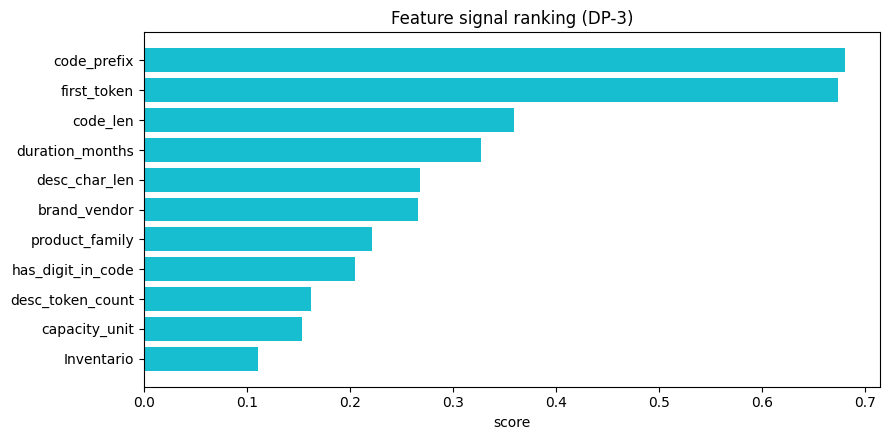

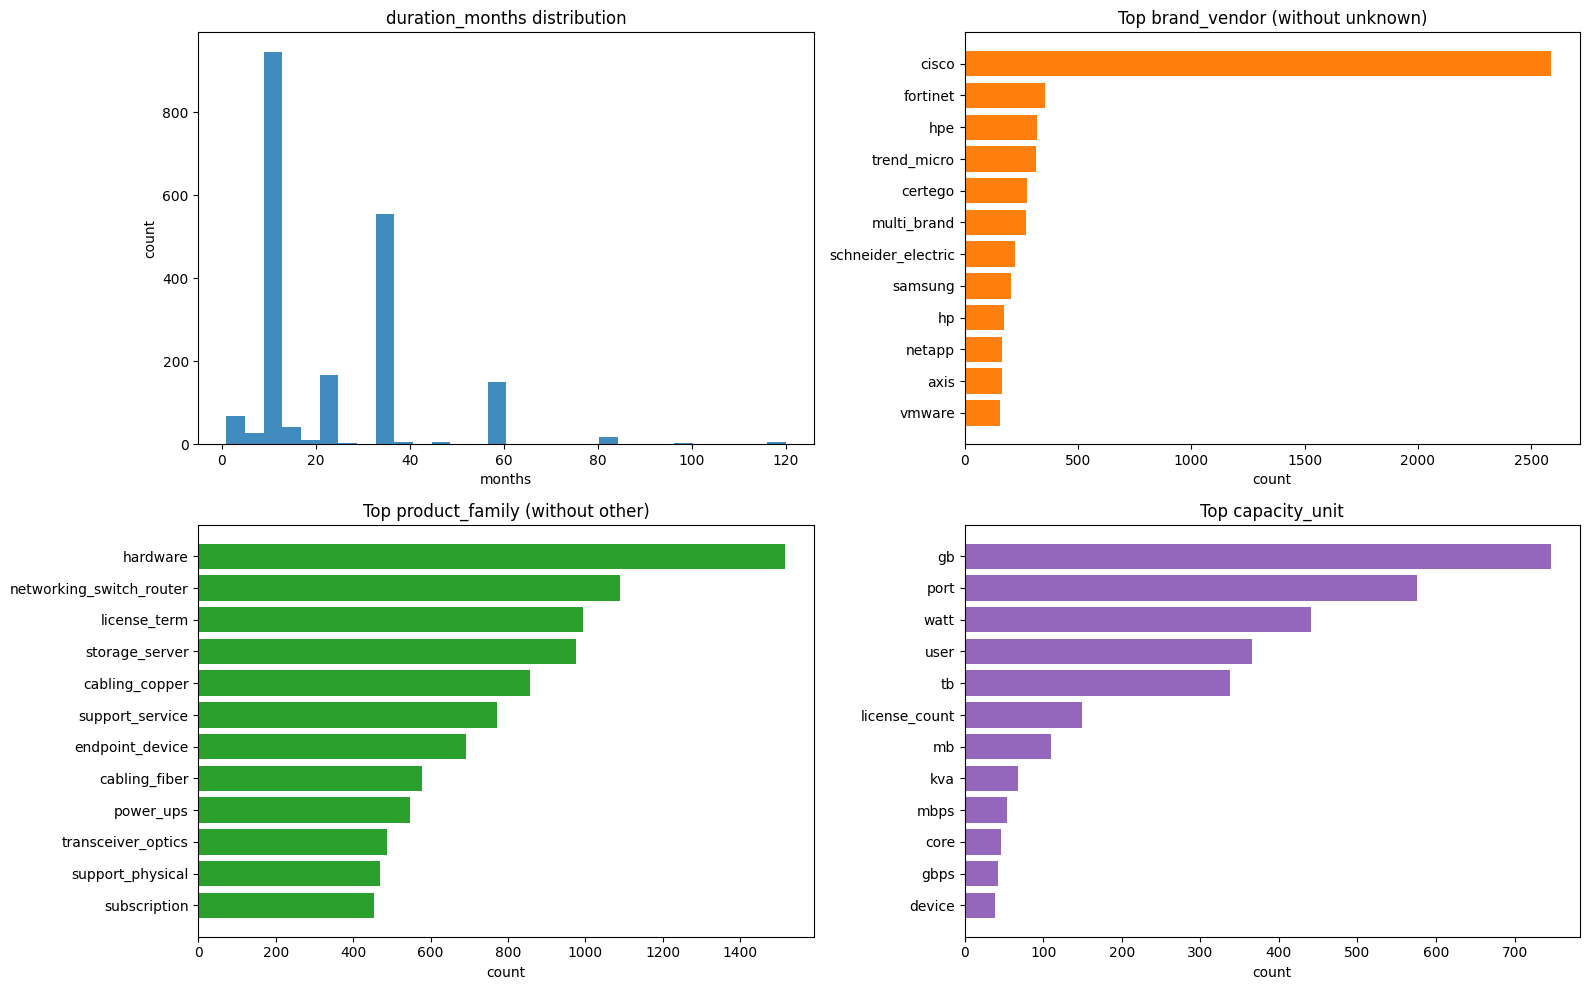

In [ ]:
df_feat = df_clean.copy()

code_s = df_feat[code_col].astype(str).str.strip().str.upper()
desc_s = df_feat[desc_col].astype(str)
desc_norm = (
    desc_s.str.lower()
    .str.replace(r'[_/\-]+', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

alpha_prefix = code_s.str.extract(r'^([A-Z]+)', expand=False)
num_prefix2 = code_s.str.extract(r'^(\d{2})', expand=False)
df_feat['code_prefix'] = alpha_prefix.fillna(num_prefix2).fillna('OTHER')
df_feat['code_len'] = code_s.str.len()
df_feat['desc_char_len'] = desc_s.str.len()
df_feat['desc_token_count'] = desc_s.str.findall(r'[A-Za-z0-9]+').str.len()
df_feat['has_digit_in_code'] = code_s.str.contains(r'\d', regex=True).astype(int)
df_feat['first_token'] = desc_norm.str.extract(r'([a-z0-9]+)', expand=False).fillna('none')


DURATION_CONTEXT_RE = r'(licenz|license|subscription|sottoscrizion|renewal|rinnovo|support|assistenza|manutenzion|warrant|garanzi|contract|carepack|smartnet|service|mese|mesi|month|months|anno|anni|year|years)'


def derive_duration_months(text: str):
    if pd.isna(text):
        return np.nan
    s = str(text).lower().replace(',', '.')
    values = []

    long_patterns = [
        (r'\b(\d{1,3}(?:\.\d+)?)\s*(?:month|months|mese|mesi|mo|mos|mth|mths)\b', 1.0),
        (r'\b(\d{1,2}(?:\.\d+)?)\s*(?:year|years|yr|yrs|anno|anni)\b', 12.0),
    ]
    short_patterns = [
        (r'\b(\d{1,3})\s*m\b', 1.0),
        (r'\b(\d{1,2})\s*y\b', 12.0),
    ]

    for pat, mult in long_patterns:
        for m in re.findall(pat, s):
            try:
                v = float(m) * mult
            except ValueError:
                continue
            if 1 <= v <= 240:
                values.append(v)

    if re.search(DURATION_CONTEXT_RE, s):
        for pat, mult in short_patterns:
            for m in re.findall(pat, s):
                try:
                    v = float(m) * mult
                except ValueError:
                    continue
                if 1 <= v <= 240:
                    values.append(v)

    if not values:
        return np.nan
    return float(max(values))


# STEP 1) Data-driven discovery: find explicit description <-> LOB patterns.
# LOB-token association matrix (before brand/product-family extraction).
LOB_ASSOC_TOP_LOBS = 12
LOB_ASSOC_MIN_LOB_ROWS = 100
LOB_ASSOC_MIN_TOKEN_LEN = 3
LOB_ASSOC_MIN_TOKEN_SUPPORT = 15
LOB_ASSOC_TOP_TOKEN_COLS = 18

lob_series = df_feat[target_col].astype(str)
lob_row_counts = lob_series.value_counts()
major_lobs = lob_row_counts[lob_row_counts >= LOB_ASSOC_MIN_LOB_ROWS].head(LOB_ASSOC_TOP_LOBS).index
if len(major_lobs) == 0:
    major_lobs = lob_row_counts.head(LOB_ASSOC_TOP_LOBS).index

lob_assoc_stopwords = {
    'the', 'and', 'for', 'with', 'from', 'per', 'con', 'del', 'della', 'delle', 'dei', 'degli', 'dell',
    'una', 'uno', 'all', 'non', 'use', 'usare', 'new', 'kit', 'model', 'modello', 'version', 'upgrade',
    'service', 'services', 'support', 'contract', 'license', 'licenses', 'licenza', 'licenze', 'rinnovo',
    'software', 'hardware', 'anno', 'anni', 'year', 'years', 'month', 'months', 'pack', 'bundle',
    'descrizione', 'articolo', 'item', 'pz', 'nr', 'n', 'cad', 'pezzi',
}

# Binary token presence per row (not raw term frequency) for cleaner association metrics.
lob_token_rows = pd.DataFrame({
    'row_id': np.arange(len(df_feat)),
    'lob': lob_series,
    'token': desc_norm.str.findall(r'[a-z0-9]+'),
}).explode('token')

lob_token_rows['token'] = lob_token_rows['token'].astype(str)
lob_token_rows = lob_token_rows[
    lob_token_rows['token'].str.len().ge(LOB_ASSOC_MIN_TOKEN_LEN)
    & ~lob_token_rows['token'].str.fullmatch(r'\d+')
    & ~lob_token_rows['token'].isin(lob_assoc_stopwords)
].drop_duplicates(['row_id', 'token'])

if lob_token_rows.empty:
    lob_assoc_df = pd.DataFrame(columns=['lob', 'token', 'support', 'p_token_lob', 'p_token', 'lift', 'p_lob_given_token', 'association_score'])
    lob_top_token_df = pd.DataFrame(columns=['lob', 'lob_rows', 'top_token', 'support', 'token_share_in_lob', 'lift', 'p_lob_given_token', 'association_score'])
    lob_token_lift_matrix = pd.DataFrame()
else:
    total_rows = len(df_feat)

    # Global token support (rows containing token).
    token_support_global = (
        lob_token_rows.groupby('token')['row_id']
        .nunique()
        .rename('token_support_global')
        .reset_index()
    )

    # LOB-token support restricted to major LOBs.
    major_rows = lob_token_rows[lob_token_rows['lob'].isin(major_lobs)].copy()
    lob_token_support = (
        major_rows.groupby(['lob', 'token'])['row_id']
        .nunique()
        .rename('support')
        .reset_index()
    )

    lob_assoc_df = (
        lob_token_support
        .merge(token_support_global, on='token', how='left')
        .assign(
            lob_rows=lambda d: d['lob'].map(lob_row_counts).astype(int),
            p_token_lob=lambda d: d['support'] / d['lob_rows'],
            p_token=lambda d: d['token_support_global'] / total_rows,
            p_lob_given_token=lambda d: d['support'] / d['token_support_global'],
        )
    )
    lob_assoc_df['lift'] = lob_assoc_df['p_token_lob'] / lob_assoc_df['p_token'].replace(0, np.nan)
    lob_assoc_df['association_score'] = (
        np.log1p(lob_assoc_df['support'])
        * lob_assoc_df['lift'].fillna(0)
        * lob_assoc_df['p_lob_given_token'].fillna(0)
    )

    lob_assoc_df = lob_assoc_df[lob_assoc_df['support'] >= LOB_ASSOC_MIN_TOKEN_SUPPORT].copy()

    if lob_assoc_df.empty:
        lob_top_token_df = pd.DataFrame(columns=['lob', 'lob_rows', 'top_token', 'support', 'token_share_in_lob', 'lift', 'p_lob_given_token', 'association_score'])
        lob_token_lift_matrix = pd.DataFrame()
    else:
        lob_top_token_df = (
            lob_assoc_df.sort_values(['lob', 'association_score', 'support'], ascending=[True, False, False])
            .drop_duplicates('lob', keep='first')
            .rename(columns={'token': 'top_token'})
        )
        lob_top_token_df['token_share_in_lob'] = lob_top_token_df['support'] / lob_top_token_df['lob_rows']
        lob_top_token_df = (
            lob_top_token_df[['lob', 'lob_rows', 'top_token', 'support', 'token_share_in_lob', 'lift', 'p_lob_given_token', 'association_score']]
            .sort_values('lob_rows', ascending=False)
            .reset_index(drop=True)
        )

        matrix_tokens = (
            lob_assoc_df.groupby('token')['support']
            .sum()
            .sort_values(ascending=False)
            .head(LOB_ASSOC_TOP_TOKEN_COLS)
            .index
        )

        lob_token_lift_matrix = (
            lob_assoc_df[lob_assoc_df['token'].isin(matrix_tokens)]
            .pivot_table(index='lob', columns='token', values='lift', aggfunc='mean', fill_value=0)
        )
        lob_token_lift_matrix = lob_token_lift_matrix.reindex(list(major_lobs), fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(19, 8))

if 'lob_token_lift_matrix' not in globals() or lob_token_lift_matrix.empty:
    axes[0].axis('off')
    axes[0].text(0.2, 0.5, 'No LOB-token association data', fontsize=11)
else:
    # log2(lift) stabilizes large lift values and keeps interpretation clear.
    lift_log = np.log2(lob_token_lift_matrix.replace(0, np.nan)).fillna(0)
    im = axes[0].imshow(lift_log.values, aspect='auto', cmap='YlOrRd')
    axes[0].set_title('Token-LOB association (log2 lift)')
    axes[0].set_xticks(range(len(lift_log.columns)))
    axes[0].set_xticklabels(lift_log.columns, rotation=45, ha='right')
    axes[0].set_yticks(range(len(lift_log.index)))
    axes[0].set_yticklabels(lift_log.index)
    axes[0].set_xlabel('token')
    axes[0].set_ylabel('LOB')
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

if 'lob_top_token_df' not in globals() or lob_top_token_df.empty:
    axes[1].axis('off')
    axes[1].text(0.2, 0.5, 'No top token per LOB', fontsize=11)
else:
    plot_df = lob_top_token_df.head(LOB_ASSOC_TOP_LOBS).copy()
    labels = plot_df['lob'].astype(str) + ' : ' + plot_df['top_token'].astype(str)
    vals = (plot_df['token_share_in_lob'] * 100).values
    axes[1].barh(labels.iloc[::-1], vals[::-1], color='#8c564b')
    axes[1].set_title('Top associated token per major LOB')
    axes[1].set_xlabel('rows in LOB containing token (%)')

plt.tight_layout()
plt.show()

# LOB-bigram association matrix (word combinations for product-family ideation).
LOB_BIGRAM_MIN_SUPPORT = 8
LOB_BIGRAM_TOP_COLS = 16


def _clean_tokens_for_phrase(tokens):
    return [
        t for t in tokens
        if len(t) >= LOB_ASSOC_MIN_TOKEN_LEN
        and not t.isdigit()
        and t not in lob_assoc_stopwords
    ]


lob_phrase_rows = pd.DataFrame({
    'row_id': np.arange(len(df_feat)),
    'lob': lob_series,
    'tokens': desc_norm.str.findall(r'[a-z0-9]+'),
})

lob_phrase_rows['tokens'] = lob_phrase_rows['tokens'].apply(_clean_tokens_for_phrase)
lob_phrase_rows['bigram'] = lob_phrase_rows['tokens'].apply(
    lambda toks: [f"{toks[i]} {toks[i + 1]}" for i in range(len(toks) - 1)] if len(toks) >= 2 else []
)

lob_bigram_rows = lob_phrase_rows[['row_id', 'lob', 'bigram']].explode('bigram')
lob_bigram_rows = lob_bigram_rows.dropna(subset=['bigram']).drop_duplicates(['row_id', 'bigram'])

if lob_bigram_rows.empty:
    lob_bigram_assoc_df = pd.DataFrame(columns=['lob', 'bigram', 'support', 'p_bigram_lob', 'p_bigram', 'lift', 'p_lob_given_bigram', 'association_score'])
    lob_top_bigram_df = pd.DataFrame(columns=['lob', 'lob_rows', 'top_bigram', 'support', 'bigram_share_in_lob', 'lift', 'p_lob_given_bigram', 'association_score'])
    lob_bigram_lift_matrix = pd.DataFrame()
else:
    bigram_support_global = (
        lob_bigram_rows.groupby('bigram')['row_id']
        .nunique()
        .rename('bigram_support_global')
        .reset_index()
    )

    major_bigram_rows = lob_bigram_rows[lob_bigram_rows['lob'].isin(major_lobs)].copy()
    lob_bigram_support = (
        major_bigram_rows.groupby(['lob', 'bigram'])['row_id']
        .nunique()
        .rename('support')
        .reset_index()
    )

    lob_bigram_assoc_df = (
        lob_bigram_support
        .merge(bigram_support_global, on='bigram', how='left')
        .assign(
            lob_rows=lambda d: d['lob'].map(lob_row_counts).astype(int),
            p_bigram_lob=lambda d: d['support'] / d['lob_rows'],
            p_bigram=lambda d: d['bigram_support_global'] / len(df_feat),
            p_lob_given_bigram=lambda d: d['support'] / d['bigram_support_global'],
        )
    )
    lob_bigram_assoc_df['lift'] = lob_bigram_assoc_df['p_bigram_lob'] / lob_bigram_assoc_df['p_bigram'].replace(0, np.nan)
    lob_bigram_assoc_df['association_score'] = (
        np.log1p(lob_bigram_assoc_df['support'])
        * lob_bigram_assoc_df['lift'].fillna(0)
        * lob_bigram_assoc_df['p_lob_given_bigram'].fillna(0)
    )
    lob_bigram_assoc_df = lob_bigram_assoc_df[lob_bigram_assoc_df['support'] >= LOB_BIGRAM_MIN_SUPPORT].copy()

    if lob_bigram_assoc_df.empty:
        lob_top_bigram_df = pd.DataFrame(columns=['lob', 'lob_rows', 'top_bigram', 'support', 'bigram_share_in_lob', 'lift', 'p_lob_given_bigram', 'association_score'])
        lob_bigram_lift_matrix = pd.DataFrame()
    else:
        lob_top_bigram_df = (
            lob_bigram_assoc_df.sort_values(['lob', 'association_score', 'support'], ascending=[True, False, False])
            .drop_duplicates('lob', keep='first')
            .rename(columns={'bigram': 'top_bigram'})
        )
        lob_top_bigram_df['bigram_share_in_lob'] = lob_top_bigram_df['support'] / lob_top_bigram_df['lob_rows']
        lob_top_bigram_df = (
            lob_top_bigram_df[['lob', 'lob_rows', 'top_bigram', 'support', 'bigram_share_in_lob', 'lift', 'p_lob_given_bigram', 'association_score']]
            .sort_values('lob_rows', ascending=False)
            .reset_index(drop=True)
        )

        matrix_bigrams = (
            lob_bigram_assoc_df.groupby('bigram')['support']
            .sum()
            .sort_values(ascending=False)
            .head(LOB_BIGRAM_TOP_COLS)
            .index
        )

        lob_bigram_lift_matrix = (
            lob_bigram_assoc_df[lob_bigram_assoc_df['bigram'].isin(matrix_bigrams)]
            .pivot_table(index='lob', columns='bigram', values='lift', aggfunc='mean', fill_value=0)
        )
        lob_bigram_lift_matrix = lob_bigram_lift_matrix.reindex(list(major_lobs), fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(19, 8))

if 'lob_bigram_lift_matrix' not in globals() or lob_bigram_lift_matrix.empty:
    axes[0].axis('off')
    axes[0].text(0.2, 0.5, 'No LOB-bigram association data', fontsize=11)
else:
    bigram_lift_log = np.log2(lob_bigram_lift_matrix.replace(0, np.nan)).fillna(0)
    im = axes[0].imshow(bigram_lift_log.values, aspect='auto', cmap='PuRd')
    axes[0].set_title('Bigram-LOB association (log2 lift)')
    axes[0].set_xticks(range(len(bigram_lift_log.columns)))
    axes[0].set_xticklabels(bigram_lift_log.columns, rotation=45, ha='right')
    axes[0].set_yticks(range(len(bigram_lift_log.index)))
    axes[0].set_yticklabels(bigram_lift_log.index)
    axes[0].set_xlabel('bigram')
    axes[0].set_ylabel('LOB')
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

if 'lob_top_bigram_df' not in globals() or lob_top_bigram_df.empty:
    axes[1].axis('off')
    axes[1].text(0.2, 0.5, 'No top bigram per LOB', fontsize=11)
else:
    plot_df = lob_top_bigram_df.head(LOB_ASSOC_TOP_LOBS).copy()
    labels = plot_df['lob'].astype(str) + ' : ' + plot_df['top_bigram'].astype(str)
    vals = (plot_df['bigram_share_in_lob'] * 100).values
    axes[1].barh(labels.iloc[::-1], vals[::-1], color='#9467bd')
    axes[1].set_title('Top associated bigram per major LOB')
    axes[1].set_xlabel('rows in LOB containing bigram (%)')

plt.tight_layout()
plt.show()

# STEP 2) Business-rule mapping: convert discovered/business rules into structured columns.
# Partner aliases from VEM partner pages (Main + Strategic):
# https://vem.com/en/company/partners/
BRAND_PATTERNS = [
    # Strong dataset/business rules
    ('certego', r'\bcertego\b|\bpanoptikon\b'),

    # Security / networking ecosystem
    ('checkpoint', r'\bcheck\s*point\b|\bcheckpoint\b|\bcp\b(?=\s*(?:gateway|firewall|smart[- ]?1|r8[01]|quantum))|\bsandblast\b'),
    ('cisco', r'\bcisco\b|\bmeraki\b|\bsmartnet\b|\bcatalyst\b|\bnexus\b|\bucs\b|\bc9300\b|\bc9200\b|\bc9500\b|\bisr\b|\basa\b|\bwebex\b|\bdna essentials\b|\bdna advantage\b'),
    ('fortinet', r'\bfortinet\b|\bfortigate\b|\bforticare\b'),
    ('palo_alto', r'\bpalo alto\b|\bpanw\b|\bprisma\b'),
    ('juniper', r'\bjuniper\b'),
    ('aruba', r'\baruba\b'),
    ('forcepoint', r'\bforcepoint\b'),
    ('radware', r'\bradware\b'),
    ('tufin', r'\btufin\b'),
    ('netwrix', r'\bnetwrix\b'),
    ('cohesity', r'\bcohesity\b'),
    ('netapp', r'\bnetapp\b|\bnet app\b|\bontap\b|\b\baff\b'),

    # Partners / strategic vendors
    ('axis', r'\baxis communications\b|\baxis\b'),
    ('barco', r'\bbarco\b'),
    ('citrix', r'\bcitrix\b'),
    ('commscope', r'\bcommscope\b'),
    ('crestron', r'\bcrestron\b'),
    ('cyber_guru', r'\bcyber\s+guru\b'),
    ('jabra', r'\bjabra\b'),
    ('milestone', r'\bmilestone\b'),
    ('nutanix', r'\bnutanix\b'),
    ('panduit', r'\bpanduit\b'),
    ('rsa', r'\brsa security\b|\brsa\b(?=\s*(?:secureid|netwitness|identity))'),
    ('schneider_electric', r'\bschneider electric\b|\bapc\b|\bsmart ups\b'),
    ('spectralink', r'\bspectralink\b|\bspectra\s*link\b'),
    ('samsung', r'\bsamsung\b|\bgalaxy\b'),
    ('trend_micro', r'\btrend micro\b|\bvision one\b|\bapex one\b|\bdeep security\b'),

    # Existing software/hardware ecosystem
    ('microsoft', r'\bmicrosoft\b|\bwindows\b|\boffice\s?365\b|\bm365\b'),
    ('hpe', r'\bhpe\b|\bhp enterprise\b|\bfoundation care\b|\bcarepack\b'),
    ('hp', r'\bhp\b(?!\s*enterprise)'),
    ('dell', r'\bdell\b|\bemc\b'),
    ('lenovo', r'\blenovo\b'),
    ('vmware', r'\bvmware\b|\bvsphere\b|\bvcenter\b|\bvmware by broadcom\b'),
    ('autodesk', r'\bautodesk\b'),
    ('adobe', r'\badobe\b|\bcreative cloud\b'),
    ('veeam', r'\bveeam\b'),
    ('oracle', r'\boracle\b'),
    ('ibm', r'\bibm\b'),
    ('aws', r'\baws\b|\bamazon web services\b'),
    ('google', r'\bgoogle\b|\bworkspace\b|\bgcp\b'),
    ('sophos', r'\bsophos\b'),
    ('qnap', r'\bqnap\b'),
    ('synology', r'\bsynology\b'),
    ('red_hat', r'\bred hat\b'),
    ('rubrik', r'\brubrik\b'),

    # New candidates from unknown-token analysis
    ('apple', r'\bapple\b|\biphone\b|\bipad\b|\bmacbook\b|\bmac\b'),
    ('intel', r'\bintel\b'),
    ('logitech', r'\blogitech\b'),
    ('imagicle', r'\bimagicle\b'),
    ('quantum', r'\bquantum\b'),
    ('hegel', r'\bhegel\b'),
    ('nokia', r'\bnokia\b'),
    ('ericsson', r'\bericsson\b'),
]

def map_brand_vendor_from_rules(text: str) -> str:
    if pd.isna(text):
        return 'unknown'
    s = str(text).lower()
    hits = [brand for brand, pat in BRAND_PATTERNS if re.search(pat, s)]
    if not hits:
        return 'unknown'
    uniq = list(dict.fromkeys(hits))
    if len(uniq) > 1:
        return 'multi_brand'
    return uniq[0]


SERVICE_WORDS_RE = r'(assistenza|support|manutenzion|maintenance|sottoscrizion|subscription|canone|helpdesk|sla|smartnet|carepack|garanzi|warrant)'
PHYSICAL_SUPPORT_RE = r'(staffa|staffe|bracket|brackets|shelf|shelves|rail|rack kit|supporto fisico|mount kit|wall mount|din rail)'


# LOB-informed product family mapping from description patterns (no target leakage).
def map_product_family_from_rules(text: str) -> str:
    if pd.isna(text):
        return 'other'
    s = str(text).lower()

    # 1) Contract/service/license logic
    if re.search(r'(bundle|pacchetto|kit)\b', s) and re.search(SERVICE_WORDS_RE, s):
        return 'bundle_hw_sw_support'
    if re.search(r'(renew|rinnovo)\s+(normal|subs|subscription)|annual subscription|subscription package', s):
        return 'subscription_renewal'
    if re.search(r'(rinnovo|renewal).*(licenz|license)|(licenz|license).*(rinnovo|renewal)', s):
        return 'license_renewal'
    if re.search(r'(licenz|license).*(perpetu|perpetua)|perpetu.*(licenz|license)', s):
        return 'license_perpetual'
    if re.search(r'(sottoscrizion|subscription|abbonament|canone|m365|office 365|creative cloud|workspace)', s):
        return 'subscription'
    if re.search(r'(estension|extension).*(garanzi|warrant)|warrant.*(extend|extension)', s):
        return 'warranty_extension'
    if re.search(r'(garanzi|warrant)', s):
        return 'warranty_standard'
    if re.search(r'(manutenzion|maintenance)', s):
        return 'maintenance_service'
    if re.search(PHYSICAL_SUPPORT_RE, s):
        return 'support_physical'
    if re.search(r'(support|assistenza|helpdesk|sla|smartnet|carepack|foundation care)', s):
        return 'support_service'
    if re.search(r'(licenz|license)', s):
        return 'license_term'

    # 2) LOB-discriminative hardware/software families from token/bigram patterns
    if re.search(r'(next generation|threat prevention|endpoint security|malware prevention|sandblast|security appliance|xdr|deep security|smart protection|firewall)', s):
        return 'security_appliance'
    if re.search(r'(catalyst|nexus|switch|router|wireless controller|cisco isr|dna essentials|dna advantage)', s):
        return 'networking_switch_router'
    if re.search(r'(webex|voice|voip|conference|headset|speakerphone|collaboration)', s):
        return 'collaboration_uc'
    if re.search(r'(day night|camera|cctv|nvr|dvr|video surveillance)', s):
        return 'surveillance_video'
    if re.search(r'(ontap|\baff\b|12g sas|storage|nas|san|server|blade|ssd|hdd|disk)', s):
        return 'storage_server'
    if re.search(r'(sfp|qsfp|10gbase|transceiver|gbic)', s):
        return 'transceiver_optics'
    if re.search(r'(om3|om4|fiber|ottic|pigtail|duplex lszh|active optical)', s):
        return 'cabling_fiber'
    if re.search(r'(cat\s*\d|\brj45\b|\butp\b|\bftp\b|patch cord|cavo rame|ethernet cable)', s):
        return 'cabling_copper'
    if re.search(r'(armadio|rack pdu|rack mount|cabinet|porta anteriore|pavimento)', s):
        return 'rack_infrastructure'
    if re.search(r'(smart ups|ups|power supply|power cord|alimentazione|psu)', s):
        return 'power_ups'
    if re.search(r'(samsung galaxy|iphone|ipad|monitor|notebook|laptop|desktop|pc|tablet|smartphone)', s):
        return 'endpoint_device'

    # 3) Generic fallbacks
    if re.search(r'(software|antivirus|windows|office|autodesk|adobe|vmware|oracle|sap|sql|cloud)', s):
        return 'software'
    if re.search(r'(appliance|module|modulo|device|hardware|server|switch|router|rack|cavo|cable)', s):
        return 'hardware'

    return 'other'


CAPACITY_PATTERNS = [
    ('tb', r'\b\d+(?:[.,]\d+)?\s*tb\b'),
    ('gb', r'\b\d+(?:[.,]\d+)?\s*gb\b'),
    ('mb', r'\b\d+(?:[.,]\d+)?\s*mb\b'),
    ('kb', r'\b\d+(?:[.,]\d+)?\s*kb\b'),
    ('pb', r'\b\d+(?:[.,]\d+)?\s*pb\b'),
    ('gbps', r'\b\d+(?:[.,]\d+)?\s*g(?:b|bit)ps\b'),
    ('mbps', r'\b\d+(?:[.,]\d+)?\s*m(?:b|bit)ps\b'),
    ('core', r'\b\d+\s*(?:core|cores|vcore|vcpu)\b'),
    ('user', r'\b\d+\s*(?:user|users|utente|utenti)\b'),
    ('device', r'\b\d+\s*(?:device|devices|dispositivo|dispositivi)\b'),
    ('port', r'\b\d+\s*(?:port|ports|porte)\b'),
    ('license_count', r'\b\d+\s*(?:licenz[ae]|license[s]?)\b'),
    ('kva', r'\b\d+(?:[.,]\d+)?\s*kva\b'),
    ('watt', r'\b\d+(?:[.,]\d+)?\s*w\b'),
]


def derive_capacity_unit(text: str) -> str:
    if pd.isna(text):
        return 'none'
    s = str(text).lower()
    for unit, pat in CAPACITY_PATTERNS:
        if re.search(pat, s):
            return unit
    return 'none'


df_feat['duration_months'] = desc_norm.apply(derive_duration_months)
df_feat['brand_vendor'] = desc_norm.apply(map_brand_vendor_from_rules)
df_feat['product_family'] = desc_norm.apply(map_product_family_from_rules)
df_feat['capacity_unit'] = desc_norm.apply(derive_capacity_unit)

coverage_df = pd.DataFrame([
    {
        'feature': 'duration_months',
        'filled_ratio': float(df_feat['duration_months'].notna().mean()),
        'distinct_values': int(df_feat['duration_months'].nunique(dropna=True)),
    },
    {
        'feature': 'brand_vendor',
        'filled_ratio': float((df_feat['brand_vendor'] != 'unknown').mean()),
        'distinct_values': int(df_feat['brand_vendor'].nunique(dropna=True)),
    },
    {
        'feature': 'product_family',
        'filled_ratio': float((df_feat['product_family'] != 'other').mean()),
        'distinct_values': int(df_feat['product_family'].nunique(dropna=True)),
    },
    {
        'feature': 'capacity_unit',
        'filled_ratio': float((df_feat['capacity_unit'] != 'none').mean()),
        'distinct_values': int(df_feat['capacity_unit'].nunique(dropna=True)),
    },
])

print('New feature coverage (non-default share):')
display(coverage_df)

preview_cols = [desc_col, 'duration_months', 'brand_vendor', 'product_family', 'capacity_unit']
display(df_feat[preview_cols].head(12))

# Validate hypothesis: "first word often equals brand".
FIRST_TOKEN_BRAND_MAP = {
    'panoptikon': 'certego',

    # Core network/security vendors
    'cisco': 'cisco', 'meraki': 'cisco', 'catalyst': 'cisco', 'nexus': 'cisco', 'ucs': 'cisco', 'webex': 'cisco',
    'fortinet': 'fortinet', 'fortigate': 'fortinet', 'forticare': 'fortinet',
    'checkpoint': 'checkpoint', 'check': 'checkpoint',
    'trend': 'trend_micro', 'apex': 'trend_micro',
    'netapp': 'netapp', 'cohesity': 'cohesity', 'aruba': 'aruba', 'juniper': 'juniper',

    # Partners and ecosystem
    'axis': 'axis', 'jabra': 'jabra', 'netwrix': 'netwrix', 'cyber': 'cyber_guru',
    'schneider': 'schneider_electric', 'apc': 'schneider_electric',
    'hpe': 'hpe', 'hp': 'hp', 'dell': 'dell', 'lenovo': 'lenovo',
    'samsung': 'samsung', 'galaxy': 'samsung',
    'microsoft': 'microsoft', 'windows': 'microsoft',
    'vmware': 'vmware', 'veeam': 'veeam',
    'aws': 'aws', 'amazon': 'aws', 'google': 'google',

    # Added from unknown-candidate analysis
    'intel': 'intel', 'logitech': 'logitech', 'apple': 'apple', 'iphone': 'apple',
    'imagicle': 'imagicle', 'quantum': 'quantum', 'hegel': 'hegel',
    'nokia': 'nokia', 'ericsson': 'ericsson',
}

df_feat['brand_from_first_token'] = df_feat['first_token'].map(FIRST_TOKEN_BRAND_MAP).fillna('unknown')

known_brand = df_feat['brand_vendor'].ne('unknown')
known_first = df_feat['brand_from_first_token'].ne('unknown')

status = np.select(
    [
        known_first & known_brand & df_feat['brand_from_first_token'].eq(df_feat['brand_vendor']),
        known_first & known_brand & df_feat['brand_from_first_token'].ne(df_feat['brand_vendor']),
        known_first & ~known_brand,
        ~known_first & known_brand,
    ],
    [
        'first_token_matches_brand',
        'first_token_conflicts_brand',
        'first_token_only',
        'brand_only_not_in_first_token',
    ],
    default='neither_detected'
)

df_feat['first_token_brand_status'] = status

# Proxy metrics: how reliable is first-token heuristic where brand is known.
precision_proxy = float(
    (known_first & known_brand & df_feat['brand_from_first_token'].eq(df_feat['brand_vendor'])).sum()
    / max((known_first & known_brand).sum(), 1)
)
recall_proxy = float(
    (known_first & known_brand & df_feat['brand_from_first_token'].eq(df_feat['brand_vendor'])).sum()
    / max(known_brand.sum(), 1)
)

first_token_eval = pd.DataFrame([
    {
        'metric': 'first_token_brand_precision_proxy',
        'value': precision_proxy,
        'note': 'among rows where both first-token and regex brand exist',
    },
    {
        'metric': 'first_token_brand_recall_proxy',
        'value': recall_proxy,
        'note': 'share of regex-known brands recovered by first-token heuristic',
    },
    {
        'metric': 'rows_with_known_brand_vendor',
        'value': int(known_brand.sum()),
        'note': 'brand_vendor != unknown',
    },
    {
        'metric': 'rows_with_known_first_token_brand',
        'value': int(known_first.sum()),
        'note': 'first token mapped to known brand alias',
    },
])

print('First-token vs brand_vendor check:')
display(first_token_eval)

status_counts = df_feat['first_token_brand_status'].value_counts()
display(status_counts.rename_axis('status').reset_index(name='count'))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

status_counts.plot(kind='bar', ax=axes[0], color='#1f77b4')
axes[0].set_title('First-token heuristic vs extracted brand')
axes[0].set_xlabel('status')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=20)

mismatch = df_feat.loc[df_feat['first_token_brand_status'].eq('first_token_conflicts_brand'), ['first_token', 'brand_vendor']].copy()
if mismatch.empty:
    axes[1].axis('off')
    axes[1].text(0.2, 0.5, 'No first-token conflicts', fontsize=11)
else:
    mismatch['pair'] = mismatch['first_token'] + ' -> ' + mismatch['brand_vendor']
    top_pairs = mismatch['pair'].value_counts().head(12).sort_values()
    axes[1].barh(top_pairs.index, top_pairs.values, color='#d62728')
    axes[1].set_title('Top first-token conflicts')
    axes[1].set_xlabel('count')

plt.tight_layout()
plt.show()



# Unknown-brand diagnostics: frequent words inside rows still tagged as `unknown`.
unknown_mask = df_feat['brand_vendor'].eq('unknown')
unknown_desc = desc_norm.loc[unknown_mask].fillna('')

unknown_stopwords = {
    'the', 'and', 'for', 'with', 'from', 'per', 'con', 'del', 'della', 'delle', 'dei', 'degli', 'dell',
    'una', 'uno', 'all', 'non', 'use', 'usare', 'new', 'kit', 'model', 'modello', 'version', 'upgrade',
    'service', 'services', 'support', 'contract', 'license', 'licenses', 'licenza', 'licenze', 'rinnovo',
    'software', 'hardware', 'anno', 'anni', 'year', 'years', 'month', 'months', 'pack', 'bundle', 'item',
}

unknown_tok_df = pd.DataFrame({'token': unknown_desc.str.findall(r'[a-z0-9]+')}).explode('token')
if unknown_tok_df.empty:
    unknown_brand_token_freq = pd.DataFrame(columns=['token', 'count'])
else:
    unknown_tok_df['token'] = unknown_tok_df['token'].astype(str)
    unknown_tok_df = unknown_tok_df[
        unknown_tok_df['token'].str.len().ge(3)
        & ~unknown_tok_df['token'].str.fullmatch(r'\d+')
        & ~unknown_tok_df['token'].isin(unknown_stopwords)
    ]
    unknown_brand_token_freq = (
        unknown_tok_df['token']
        .value_counts()
        .rename_axis('token')
        .reset_index(name='count')
    )

unknown_first_token_freq = (
    df_feat.loc[unknown_mask, 'first_token']
    .astype(str)
    .loc[lambda s: s.ne('none')]
    .loc[lambda s: ~s.isin(unknown_stopwords)]
    .value_counts()
    .rename_axis('token')
    .reset_index(name='first_token_count')
)

if unknown_brand_token_freq.empty:
    unknown_brand_token_candidates = pd.DataFrame(columns=['token', 'count', 'first_token_count', 'candidate_score'])
else:
    unknown_brand_token_candidates = unknown_brand_token_freq.merge(
        unknown_first_token_freq,
        on='token',
        how='left'
    )
    unknown_brand_token_candidates['first_token_count'] = unknown_brand_token_candidates['first_token_count'].fillna(0).astype(int)
    unknown_brand_token_candidates['candidate_score'] = (
        np.log1p(unknown_brand_token_candidates['count'])
        * (1 + unknown_brand_token_candidates['first_token_count'])
    )
    unknown_brand_token_candidates = unknown_brand_token_candidates.sort_values(
        ['candidate_score', 'count'], ascending=[False, False]
    )

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

left = unknown_brand_token_freq.head(20).iloc[::-1]
if left.empty:
    axes[0].axis('off')
    axes[0].text(0.2, 0.5, 'No unknown tokens to plot', fontsize=11)
else:
    axes[0].barh(left['token'], left['count'], color='#1f77b4')
    axes[0].set_title('Unknown rows: top token frequency')
    axes[0].set_xlabel('count')

right = unknown_first_token_freq.head(20).iloc[::-1]
if right.empty:
    axes[1].axis('off')
    axes[1].text(0.2, 0.5, 'No unknown first tokens to plot', fontsize=11)
else:
    axes[1].barh(right['token'], right['first_token_count'], color='#ff7f0e')
    axes[1].set_title('Unknown rows: top first-token frequency')
    axes[1].set_xlabel('count')

plt.tight_layout()
plt.show()



# Token-to-label matrices for brand_vendor and product_family.
TOKEN_MATRIX_STOPWORDS = {
    'the', 'and', 'for', 'with', 'from', 'per', 'con', 'del', 'della', 'delle', 'dei', 'degli', 'dell',
    'una', 'uno', 'all', 'non', 'use', 'usare', 'new', 'kit', 'model', 'modello', 'version', 'upgrade',
    'service', 'services', 'support', 'contract', 'license', 'licenses', 'licenza', 'licenze', 'rinnovo',
    'software', 'hardware', 'anno', 'anni', 'year', 'years', 'month', 'months', 'pack', 'bundle',
}

mat_tok = pd.DataFrame({
    'token': desc_norm.str.findall(r'[a-z0-9]+'),
    'brand_vendor': df_feat['brand_vendor'].astype(str),
    'product_family': df_feat['product_family'].astype(str),
}).explode('token')

if mat_tok.empty:
    token_brand_matrix_norm = pd.DataFrame()
    token_family_matrix_norm = pd.DataFrame()
else:
    mat_tok['token'] = mat_tok['token'].astype(str)
    mat_tok = mat_tok[
        mat_tok['token'].str.len().ge(3)
        & ~mat_tok['token'].str.fullmatch(r'\d+')
        & ~mat_tok['token'].isin(TOKEN_MATRIX_STOPWORDS)
    ].copy()

    top_tokens = mat_tok['token'].value_counts().head(35).index

    brand_subset = mat_tok[mat_tok['brand_vendor'].ne('unknown')]
    top_brands = brand_subset['brand_vendor'].value_counts().head(10).index

    family_subset = mat_tok[mat_tok['product_family'].ne('other')]
    top_families = family_subset['product_family'].value_counts().head(10).index

    brand_mat_df = brand_subset.loc[
        brand_subset['token'].isin(top_tokens),
        ['token', 'brand_vendor']
    ].reset_index(drop=True)
    token_brand_matrix = pd.crosstab(
        brand_mat_df['token'].to_numpy(),
        brand_mat_df['brand_vendor'].to_numpy(),
        rownames=['token'],
        colnames=['brand_vendor']
    )
    token_brand_matrix = token_brand_matrix.reindex(columns=top_brands, fill_value=0)

    family_mat_df = family_subset.loc[
        family_subset['token'].isin(top_tokens),
        ['token', 'product_family']
    ].reset_index(drop=True)
    token_family_matrix = pd.crosstab(
        family_mat_df['token'].to_numpy(),
        family_mat_df['product_family'].to_numpy(),
        rownames=['token'],
        colnames=['product_family']
    )
    token_family_matrix = token_family_matrix.reindex(columns=top_families, fill_value=0)

    token_brand_matrix_norm = token_brand_matrix.div(token_brand_matrix.sum(axis=1).replace(0, 1), axis=0)
    token_family_matrix_norm = token_family_matrix.div(token_family_matrix.sum(axis=1).replace(0, 1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

if 'token_brand_matrix_norm' not in globals() or token_brand_matrix_norm.empty:
    axes[0].axis('off')
    axes[0].text(0.2, 0.5, 'No token-brand matrix data', fontsize=11)
else:
    im0 = axes[0].imshow(token_brand_matrix_norm.values, aspect='auto', cmap='YlGnBu')
    axes[0].set_title('Token -> brand_vendor matrix (row-normalized)')
    axes[0].set_xticks(range(len(token_brand_matrix_norm.columns)))
    axes[0].set_xticklabels(token_brand_matrix_norm.columns, rotation=45, ha='right')
    axes[0].set_yticks(range(len(token_brand_matrix_norm.index)))
    axes[0].set_yticklabels(token_brand_matrix_norm.index)
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

if 'token_family_matrix_norm' not in globals() or token_family_matrix_norm.empty:
    axes[1].axis('off')
    axes[1].text(0.2, 0.5, 'No token-family matrix data', fontsize=11)
else:
    im1 = axes[1].imshow(token_family_matrix_norm.values, aspect='auto', cmap='PuBuGn')
    axes[1].set_title('Token -> product_family matrix (row-normalized)')
    axes[1].set_xticks(range(len(token_family_matrix_norm.columns)))
    axes[1].set_xticklabels(token_family_matrix_norm.columns, rotation=45, ha='right')
    axes[1].set_yticks(range(len(token_family_matrix_norm.index)))
    axes[1].set_yticklabels(token_family_matrix_norm.index)
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


def weighted_purity(feature_name: str) -> float:
    tab = pd.crosstab(df_feat[feature_name], df_feat[target_col])
    if tab.empty:
        return 0.0
    support = tab.sum(axis=1)
    purity = tab.max(axis=1) / support
    return float((purity * support).sum() / support.sum())


def between_variance_ratio(feature_name: str) -> float:
    s = pd.to_numeric(df_feat[feature_name], errors='coerce')
    s_valid = s.dropna()
    if s_valid.empty:
        return 0.0
    total_var = float(s_valid.var())
    if not np.isfinite(total_var) or total_var == 0:
        return 0.0

    temp = df_feat.assign(_v=s).dropna(subset=['_v'])
    means = temp.groupby(target_col)['_v'].mean()
    weights = temp[target_col].value_counts(normalize=True).reindex(means.index).fillna(0.0)
    between_var = float((((means - s_valid.mean()) ** 2) * weights).sum())
    return between_var / total_var


cat_features = ['code_prefix', 'first_token', 'brand_vendor', 'product_family', 'capacity_unit']
if inventory_col and inventory_col in df_feat.columns:
    cat_features.append(inventory_col)

num_features = ['code_len', 'desc_char_len', 'desc_token_count', 'has_digit_in_code', 'duration_months']

signal_rows = []
for f in cat_features:
    signal_rows.append({'feature': f, 'score': weighted_purity(f), 'score_type': 'weighted_purity'})
for f in num_features:
    signal_rows.append({'feature': f, 'score': between_variance_ratio(f), 'score_type': 'between_variance_ratio'})

signal_df = pd.DataFrame(signal_rows).sort_values('score', ascending=False)
display(signal_df)

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_sig = signal_df.sort_values('score', ascending=True)
ax.barh(plot_sig['feature'], plot_sig['score'], color='#17becf')
ax.set_title('Feature signal ranking (DP-3)')
ax.set_xlabel('score')
plt.tight_layout()
plt.show()


def plot_top_bar(ax, series, title, color, top_n=12, drop_values=None):
    s = series.astype(str)
    if drop_values:
        s = s[~s.isin(drop_values)]
    counts = s.value_counts().head(top_n).sort_values()
    if counts.empty:
        ax.axis('off')
        ax.text(0.2, 0.5, 'No rows to plot', fontsize=11)
        return
    ax.barh(counts.index, counts.values, color=color)
    ax.set_title(title)
    ax.set_xlabel('count')


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

duration_vals = df_feat['duration_months'].dropna()
if duration_vals.empty:
    axes[0, 0].axis('off')
    axes[0, 0].text(0.2, 0.5, 'No duration values extracted', fontsize=11)
else:
    axes[0, 0].hist(duration_vals, bins=30, color='#1f77b4', alpha=0.85)
    axes[0, 0].set_title('duration_months distribution')
    axes[0, 0].set_xlabel('months')
    axes[0, 0].set_ylabel('count')

plot_top_bar(axes[0, 1], df_feat['brand_vendor'], 'Top brand_vendor (without unknown)', '#ff7f0e', top_n=12, drop_values=['unknown'])
plot_top_bar(axes[1, 0], df_feat['product_family'], 'Top product_family (without other)', '#2ca02c', top_n=12, drop_values=['other'])
plot_top_bar(axes[1, 1], df_feat['capacity_unit'], 'Top capacity_unit', '#9467bd', top_n=12, drop_values=['none'])

plt.tight_layout()
plt.show()










## DP-4) Encode, Scale, Transform
Apply categorical encoding and numeric scaling/transforms, including new extracted features.

Visualizations:
- before/after distributions for skewed numeric features (`desc_char_len`, `duration_months`).


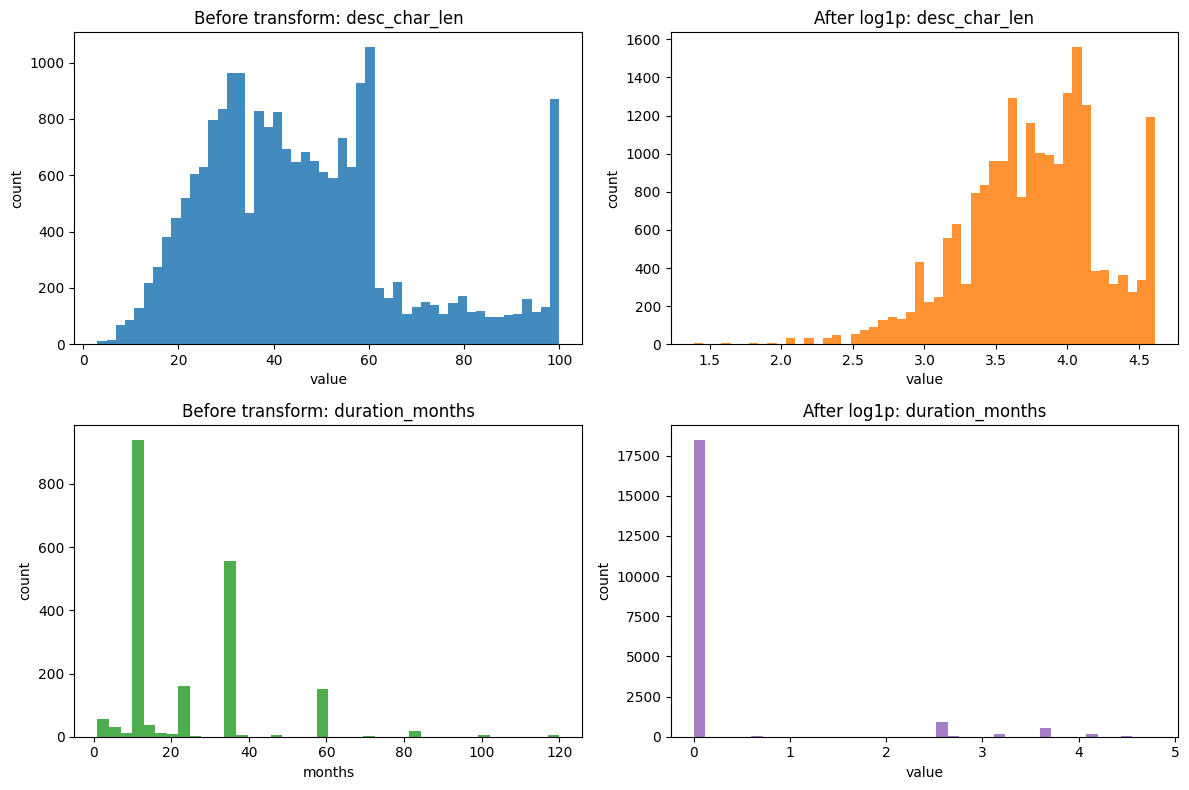

Encoded table shape: (20499, 59)


In [ ]:
df_model = df_feat.copy()

# Top-prefix one-hot encoding.
top_prefix = df_model['code_prefix'].value_counts().head(15).index
df_model['code_prefix_top'] = np.where(df_model['code_prefix'].isin(top_prefix), df_model['code_prefix'], 'OTHER')
ohe_parts = [pd.get_dummies(df_model['code_prefix_top'], prefix='pref', dtype='int8')]

# Optional inventory encoding (top categories only).
if inventory_col and inventory_col in df_model.columns:
    inv_series = df_model[inventory_col].astype(str)
    top_inv = inv_series.value_counts().head(10).index
    inv_top = np.where(inv_series.isin(top_inv), inv_series, 'OTHER')
    ohe_parts.append(pd.get_dummies(inv_top, prefix='inv', dtype='int8'))

# New categorical engineered features.
cat_specs = [
    ('brand_vendor', 'brand', 12, 'unknown'),
    ('product_family', 'pfam', 12, 'other'),
    ('capacity_unit', 'cap', 10, 'none'),
]
for col, pref, n_top, fill_value in cat_specs:
    if col not in df_model.columns:
        continue
    s = df_model[col].fillna(fill_value).astype(str)
    top_vals = s.value_counts().head(n_top).index
    s_top = np.where(s.isin(top_vals), s, fill_value)
    ohe_parts.append(pd.get_dummies(s_top, prefix=pref, dtype='int8'))

ohe_df = pd.concat(ohe_parts, axis=1)

num_cols = ['code_len', 'desc_char_len', 'desc_token_count', 'has_digit_in_code', 'duration_months']
for c in num_cols:
    if c not in df_model.columns:
        df_model[c] = np.nan

num_base = df_model[num_cols].apply(pd.to_numeric, errors='coerce')
num_base['duration_months'] = num_base['duration_months'].fillna(0.0)
num_base = num_base.fillna(num_base.median(numeric_only=True))

num_scaled = (num_base - num_base.min()) / (num_base.max() - num_base.min()).replace(0, 1)
num_scaled = num_scaled.add_suffix('_mm')

df_model['desc_char_len_log1p'] = np.log1p(pd.to_numeric(df_model['desc_char_len'], errors='coerce').fillna(0))
df_model['duration_months_log1p'] = np.log1p(pd.to_numeric(df_model['duration_months'], errors='coerce').fillna(0))

df_encoded = pd.concat([num_scaled, ohe_df], axis=1)
df_encoded['desc_char_len_log1p'] = df_model['desc_char_len_log1p'].astype(float)
df_encoded['duration_months_log1p'] = df_model['duration_months_log1p'].astype(float)
df_encoded[target_col] = df_model[target_col].values

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df_model['desc_char_len'], bins=50, color='#1f77b4', alpha=0.85)
axes[0, 0].set_title('Before transform: desc_char_len')
axes[0, 0].set_xlabel('value')
axes[0, 0].set_ylabel('count')

axes[0, 1].hist(df_model['desc_char_len_log1p'], bins=50, color='#ff7f0e', alpha=0.85)
axes[0, 1].set_title('After log1p: desc_char_len')
axes[0, 1].set_xlabel('value')
axes[0, 1].set_ylabel('count')

axes[1, 0].hist(df_model['duration_months'].dropna(), bins=40, color='#2ca02c', alpha=0.85)
axes[1, 0].set_title('Before transform: duration_months')
axes[1, 0].set_xlabel('months')
axes[1, 0].set_ylabel('count')

axes[1, 1].hist(df_model['duration_months_log1p'], bins=40, color='#9467bd', alpha=0.85)
axes[1, 1].set_title('After log1p: duration_months')
axes[1, 1].set_xlabel('value')
axes[1, 1].set_ylabel('count')

plt.tight_layout()
plt.show()

print(f'Encoded table shape: {df_encoded.shape}')
stage_sizes['encoded'] = len(df_encoded)


## DP-5) Aggregate, Bin, Reduce
Apply binning/aggregation and low-dimensional diagnostics.

Visualizations:
- target composition by bins,
- correlation heatmap,
- cumulative explained variance (SVD-based PCA view).


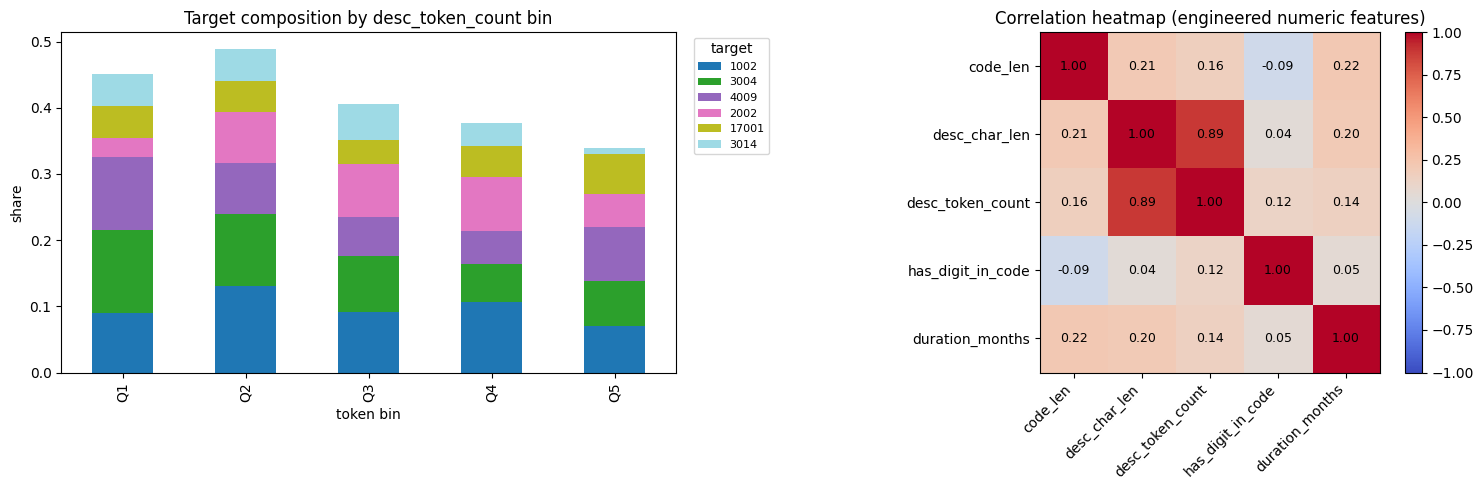

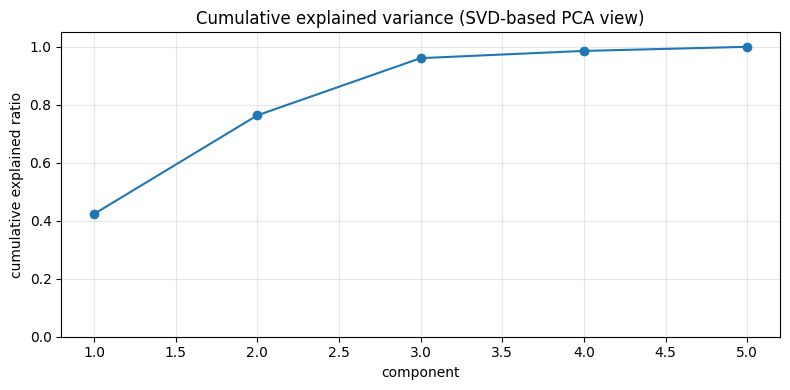

,component,explained_ratio,cumulative_ratio
0,1,0.423233,0.423233
1,2,0.340357,0.763590
2,3,0.197397,0.960987
3,4,0.024932,0.985919
4,5,0.014081,1.000000


In [ ]:
# Binning by token-count quantiles.
ranked = df_feat['desc_token_count'].rank(method='first')
bin_labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']

desc_token_bin = pd.qcut(ranked, q=5, labels=bin_labels)

bin_target = pd.crosstab(desc_token_bin, df_feat[target_col], normalize='index')
top_targets = df_feat[target_col].value_counts().head(6).index
bin_target_small = bin_target[top_targets] if len(top_targets) > 0 else bin_target

# Correlation matrix on engineered numeric features.
numeric_candidates = ['code_len', 'desc_char_len', 'desc_token_count', 'has_digit_in_code', 'duration_months']
numeric_cols = [c for c in numeric_candidates if c in df_feat.columns]
numeric_engineered = df_feat[numeric_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0)
corr = numeric_engineered.corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bin_target_small.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20')
axes[0].set_title('Target composition by desc_token_count bin')
axes[0].set_xlabel('token bin')
axes[0].set_ylabel('share')
axes[0].legend(title='target', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

im = axes[1].imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr.columns)))
axes[1].set_xticklabels(corr.columns, rotation=45, ha='right')
axes[1].set_yticks(range(len(corr.index)))
axes[1].set_yticklabels(corr.index)
axes[1].set_title('Correlation heatmap (engineered numeric features)')
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        axes[1].text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# SVD-based PCA diagnostics on scaled numeric features.
mm_cols = [c for c in df_encoded.columns if c.endswith('_mm')]
X = df_encoded[mm_cols].to_numpy(dtype=float)
X = X - X.mean(axis=0, keepdims=True)

U, S, Vt = np.linalg.svd(X, full_matrices=False)
explained = (S ** 2) / max(len(X) - 1, 1)
if explained.sum() > 0:
    explained_ratio = explained / explained.sum()
else:
    explained_ratio = explained

cum_ratio = np.cumsum(explained_ratio)
k = min(10, len(cum_ratio))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, k + 1), cum_ratio[:k], marker='o')
ax.set_title('Cumulative explained variance (SVD-based PCA view)')
ax.set_xlabel('component')
ax.set_ylabel('cumulative explained ratio')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pca_df = pd.DataFrame({
    'component': np.arange(1, len(explained_ratio) + 1),
    'explained_ratio': explained_ratio,
    'cumulative_ratio': cum_ratio,
})

display(pca_df.head(10))

stage_sizes['reduced_ready'] = len(df_encoded)


## DP-5.1) Validate Metadata Uplift
Quantify quality impact of metadata and specifically compare **legacy vs current rule-mapping** for `brand_vendor` and `product_family`.

Method:
- fixed model family (`LogisticRegression`),
- same CV splits for all variants,
- compare `baseline` vs `metadata_legacy` vs `metadata_current` on the same evaluation subset.

Visualizations:
- metric comparison bar chart across three variants,
- delta chart (legacy-baseline, current-legacy, current-baseline).


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold

# Build legacy mapping (before latest rule expansion) to isolate uplift from new business rules.
LEGACY_BRAND_PATTERNS = [
    ('certego', r'\bcertego\b|\bpanoptikon\b'),
    ('checkpoint', r'\bcheck\s*point\b|\bcheckpoint\b|\bcp\b(?=\s*(?:gateway|firewall|smart[- ]?1|r8[01]|quantum))'),
    ('cisco', r'\bcisco\b|\bmeraki\b|\bsmartnet\b|\bcatalyst\b'),
    ('cohesity', r'\bcohesity\b'),
    ('fortinet', r'\bfortinet\b|\bfortigate\b|\bforticare\b'),
    ('netapp', r'\bnetapp\b|\bnet app\b|\bontap\b'),
    ('schneider_electric', r'\bschneider electric\b|\bapc\b'),
    ('trend_micro', r'\btrend micro\b'),
    ('spectralink', r'\bspectralink\b|\bspectra\s*link\b'),
    ('axis', r'\baxis communications\b|\baxis\b(?=\s*(?:camera|cam|network))'),
    ('barco', r'\bbarco\b'),
    ('citrix', r'\bcitrix\b'),
    ('commscope', r'\bcommscope\b'),
    ('crestron', r'\bcrestron\b'),
    ('cyber_guru', r'\bcyber\s+guru\b'),
    ('forcepoint', r'\bforcepoint\b'),
    ('jabra', r'\bjabra\b'),
    ('milestone', r'\bmilestone\b'),
    ('netwrix', r'\bnetwrix\b'),
    ('nutanix', r'\bnutanix\b'),
    ('panduit', r'\bpanduit\b'),
    ('radware', r'\bradware\b'),
    ('rsa', r'\brsa security\b|\brsa\b(?=\s*(?:secureid|netwitness|identity))'),
    ('samsung', r'\bsamsung\b'),
    ('tufin', r'\btufin\b'),
    ('microsoft', r'\bmicrosoft\b|\bwindows\b|\boffice\s?365\b|\bm365\b'),
    ('hpe', r'\bhpe\b|\bhp enterprise\b|\bfoundation care\b|\bcarepack\b'),
    ('hp', r'\bhp\b(?!\s*enterprise)'),
    ('dell', r'\bdell\b|\bemc\b'),
    ('lenovo', r'\blenovo\b'),
    ('palo_alto', r'\bpalo alto\b|\bpanw\b|\bprisma\b'),
    ('juniper', r'\bjuniper\b'),
    ('aruba', r'\baruba\b'),
    ('vmware', r'\bvmware\b|\bvsphere\b|\bvcenter\b|\bvmware by broadcom\b'),
    ('autodesk', r'\bautodesk\b'),
    ('adobe', r'\badobe\b|\bcreative cloud\b'),
    ('veeam', r'\bveeam\b'),
    ('oracle', r'\boracle\b'),
    ('ibm', r'\bibm\b'),
    ('aws', r'\baws\b|\bamazon web services\b'),
    ('google', r'\bgoogle\b|\bworkspace\b|\bgcp\b'),
    ('sophos', r'\bsophos\b'),
    ('qnap', r'\bqnap\b'),
    ('synology', r'\bsynology\b'),
    ('red_hat', r'\bred hat\b'),
    ('rubrik', r'\brubrik\b'),
]


def map_brand_vendor_legacy(text: str) -> str:
    if pd.isna(text):
        return 'unknown'
    s = str(text).lower()
    hits = [brand for brand, pat in LEGACY_BRAND_PATTERNS if re.search(pat, s)]
    if not hits:
        return 'unknown'
    uniq = list(dict.fromkeys(hits))
    if len(uniq) > 1:
        return 'multi_brand'
    return uniq[0]


SERVICE_WORDS_RE_LEGACY = r'(assistenza|support|manutenzion|maintenance|sottoscrizion|subscription|canone|helpdesk|sla|smartnet|carepack|garanzi|warrant)'
PHYSICAL_SUPPORT_RE_LEGACY = r'(staffa|staffe|bracket|brackets|shelf|shelves|rail|rack kit|supporto fisico|mount kit)'


def map_product_family_legacy(text: str) -> str:
    if pd.isna(text):
        return 'other'
    s = str(text).lower()

    if re.search(r'(bundle|pacchetto|kit)\b', s) and re.search(SERVICE_WORDS_RE_LEGACY, s):
        return 'bundle_hw_sw_support'
    if re.search(PHYSICAL_SUPPORT_RE_LEGACY, s):
        return 'support_physical'
    if re.search(r'(rinnovo|renewal).*(licenz|license)|(licenz|license).*(rinnovo|renewal)', s):
        return 'license_renewal'
    if re.search(r'(licenz|license).*(perpetu|perpetua)|perpetu.*(licenz|license)', s):
        return 'license_perpetual'
    if re.search(r'(sottoscrizion|subscription|abbonament|canone|m365|office 365|creative cloud|workspace)', s):
        return 'subscription'
    if re.search(r'(estension|extension).*(garanzi|warrant)|warrant.*(extend|extension)', s):
        return 'warranty_extension'
    if re.search(r'(garanzi|warrant)', s):
        return 'warranty_standard'
    if re.search(r'(manutenzion|maintenance)', s):
        return 'maintenance_service'
    if re.search(PHYSICAL_SUPPORT_RE_LEGACY, s):
        return 'support_physical'
    if re.search(r'(support|assistenza|helpdesk|sla|smartnet|carepack|foundation care)', s):
        return 'support_service'
    if re.search(r'(licenz|license)', s):
        return 'license_term'
    if re.search(r'(server|switch|router|firewall|storage|ssd|hdd|disk|notebook|laptop|pc|monitor|stampant|printer|ups|nas|appliance|rack|staffa|bracket)', s):
        return 'hardware'
    if re.search(r'(software|antivirus|windows|office|autodesk|adobe|vmware|oracle|sap|sql|endpoint|cloud)', s):
        return 'software'
    return 'other'


# Evaluation dataset (current mapping already available in df_feat from DP-3).
eval_df = df_feat.copy()
if 'desc_norm' not in globals():
    desc_norm = (
        eval_df[desc_col].fillna('').astype(str).str.lower()
        .str.replace(r'[_/\-]+', ' ', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

eval_df['brand_vendor_legacy'] = desc_norm.apply(map_brand_vendor_legacy)
eval_df['product_family_legacy'] = desc_norm.apply(map_product_family_legacy)

y_all = eval_df[target_col].astype(str).copy()

# Keep classes with enough support for stratified CV.
MIN_SAMPLES_PER_CLASS = 3
N_SPLITS = 3
freq = y_all.value_counts()
valid_classes = freq[freq >= MIN_SAMPLES_PER_CLASS].index
mask_eval = y_all.isin(valid_classes)

# Feature groups
base_source_cols = [c for c in ['code_prefix', 'first_token', 'code_len', 'desc_char_len', 'desc_token_count', 'has_digit_in_code'] if c in eval_df.columns]
common_meta_cols = [c for c in ['duration_months', 'capacity_unit'] if c in eval_df.columns]

legacy_cols = base_source_cols + common_meta_cols + [
    c for c in ['brand_vendor_legacy', 'product_family_legacy'] if c in eval_df.columns
]
current_cols = base_source_cols + common_meta_cols + [
    c for c in ['brand_vendor', 'product_family'] if c in eval_df.columns
]


def build_matrix(df_source: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    X = df_source.loc[mask_eval, cols].copy()
    cat_like = {
        'code_prefix', 'first_token', 'capacity_unit',
        'brand_vendor', 'product_family',
        'brand_vendor_legacy', 'product_family_legacy',
    }
    cat_cols = [c for c in X.columns if c in cat_like or X[c].dtype == 'object']
    num_cols = [c for c in X.columns if c not in cat_cols]

    for c in cat_cols:
        X[c] = X[c].fillna('missing').astype(str)
    for c in num_cols:
        X[c] = pd.to_numeric(X[c], errors='coerce').fillna(-1)

    return pd.get_dummies(X, columns=cat_cols, drop_first=False)


X_base = build_matrix(eval_df, base_source_cols)
X_legacy = build_matrix(eval_df, legacy_cols)
X_current = build_matrix(eval_df, current_cols)
y_eval = y_all.loc[mask_eval]


scope_df = pd.Series({
    'rows_total': int(len(y_all)),
    'rows_eval_subset': int(len(y_eval)),
    'rows_coverage_pct': float(len(y_eval) / len(y_all) * 100) if len(y_all) else 0.0,
    'classes_total': int(y_all.nunique()),
    'classes_eval_subset': int(y_eval.nunique()),
    'baseline_feature_count': int(X_base.shape[1]),
    'legacy_feature_count': int(X_legacy.shape[1]),
    'current_feature_count': int(X_current.shape[1]),
    'legacy_unknown_brand_rows': int((eval_df.loc[mask_eval, 'brand_vendor_legacy'] == 'unknown').sum()),
    'current_unknown_brand_rows': int((eval_df.loc[mask_eval, 'brand_vendor'] == 'unknown').sum()),
    'legacy_other_family_rows': int((eval_df.loc[mask_eval, 'product_family_legacy'] == 'other').sum()),
    'current_other_family_rows': int((eval_df.loc[mask_eval, 'product_family'] == 'other').sum()),
    'cv_splits': int(N_SPLITS),
})

print('Evaluation scope:')
display(scope_df.rename_axis('metric').reset_index(name='value'))

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def evaluate_variant(X: pd.DataFrame, y: pd.Series, variant_name: str):
    fold_rows = []
    for fold_id, (tr_idx, te_idx) in enumerate(cv.split(X, y), start=1):
        model = LogisticRegression(
            max_iter=700,
            solver='lbfgs',
            C=1.0,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )
        model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = model.predict(X.iloc[te_idx])

        fold_rows.append({
            'variant': variant_name,
            'fold': fold_id,
            'accuracy': accuracy_score(y.iloc[te_idx], pred),
            'f1_weighted': f1_score(y.iloc[te_idx], pred, average='weighted'),
            'f1_macro': f1_score(y.iloc[te_idx], pred, average='macro'),
        })
    return pd.DataFrame(fold_rows)


fold_base = evaluate_variant(X_base, y_eval, 'baseline')
fold_legacy = evaluate_variant(X_legacy, y_eval, 'metadata_legacy')
fold_current = evaluate_variant(X_current, y_eval, 'metadata_current')

uplift_fold_df = pd.concat([fold_base, fold_legacy, fold_current], ignore_index=True)

summary_rows = []
for variant_name, g in uplift_fold_df.groupby('variant'):
    summary_rows.append({
        'variant': variant_name,
        'accuracy_mean': float(g['accuracy'].mean()),
        'accuracy_std': float(g['accuracy'].std(ddof=1) if len(g) > 1 else 0.0),
        'f1_weighted_mean': float(g['f1_weighted'].mean()),
        'f1_weighted_std': float(g['f1_weighted'].std(ddof=1) if len(g) > 1 else 0.0),
        'f1_macro_mean': float(g['f1_macro'].mean()),
        'f1_macro_std': float(g['f1_macro'].std(ddof=1) if len(g) > 1 else 0.0),
    })

order = ['baseline', 'metadata_legacy', 'metadata_current']
uplift_summary_df = pd.DataFrame(summary_rows)
uplift_summary_df['variant'] = pd.Categorical(uplift_summary_df['variant'], categories=order, ordered=True)
uplift_summary_df = uplift_summary_df.sort_values('variant').reset_index(drop=True)

row_base = uplift_summary_df[uplift_summary_df['variant'] == 'baseline'].iloc[0]
row_legacy = uplift_summary_df[uplift_summary_df['variant'] == 'metadata_legacy'].iloc[0]
row_current = uplift_summary_df[uplift_summary_df['variant'] == 'metadata_current'].iloc[0]

delta_df = pd.DataFrame([
    {
        'comparison': 'legacy - baseline',
        'accuracy_delta': float(row_legacy['accuracy_mean'] - row_base['accuracy_mean']),
        'f1_weighted_delta': float(row_legacy['f1_weighted_mean'] - row_base['f1_weighted_mean']),
        'f1_macro_delta': float(row_legacy['f1_macro_mean'] - row_base['f1_macro_mean']),
    },
    {
        'comparison': 'current - legacy',
        'accuracy_delta': float(row_current['accuracy_mean'] - row_legacy['accuracy_mean']),
        'f1_weighted_delta': float(row_current['f1_weighted_mean'] - row_legacy['f1_weighted_mean']),
        'f1_macro_delta': float(row_current['f1_macro_mean'] - row_legacy['f1_macro_mean']),
    },
    {
        'comparison': 'current - baseline',
        'accuracy_delta': float(row_current['accuracy_mean'] - row_base['accuracy_mean']),
        'f1_weighted_delta': float(row_current['f1_weighted_mean'] - row_base['f1_weighted_mean']),
        'f1_macro_delta': float(row_current['f1_macro_mean'] - row_base['f1_macro_mean']),
    },
])

print('Fold-level metrics:')
display(uplift_fold_df)

print('Summary (mean +/- std):')
display(uplift_summary_df)

print('Delta summary:')
display(delta_df)

metric_cols = ['accuracy_mean', 'f1_weighted_mean', 'f1_macro_mean']
metric_labels = ['accuracy', 'f1_weighted', 'f1_macro']
variants = ['baseline', 'metadata_legacy', 'metadata_current']
variant_colors = {'baseline': '#7f7f7f', 'metadata_legacy': '#1f77b4', 'metadata_current': '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(metric_labels))
bar_w = 0.25

for i, v in enumerate(variants):
    row = uplift_summary_df[uplift_summary_df['variant'] == v].iloc[0]
    vals = [float(row[m]) for m in metric_cols]
    axes[0].bar(x + (i - 1) * bar_w, vals, width=bar_w, label=v, color=variant_colors[v])
    for j, val in enumerate(vals):
        axes[0].text(x[j] + (i - 1) * bar_w, val, f'{val:.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_labels)
axes[0].set_ylim(0, max(uplift_summary_df[metric_cols].max()) * 1.25)
axes[0].set_title('Model quality across metadata variants')
axes[0].set_ylabel('score')
axes[0].legend()

plot_delta = delta_df.melt(id_vars='comparison', var_name='metric', value_name='delta')
plot_delta['metric'] = plot_delta['metric'].str.replace('_delta', '', regex=False)

metric_order = ['accuracy', 'f1_weighted', 'f1_macro']
comp_order = ['legacy - baseline', 'current - legacy', 'current - baseline']
comp_shift = {'legacy - baseline': -bar_w, 'current - legacy': 0.0, 'current - baseline': bar_w}
comp_colors = {'legacy - baseline': '#1f77b4', 'current - legacy': '#ff7f0e', 'current - baseline': '#2ca02c'}

for comp in comp_order:
    vals = []
    for m in metric_order:
        v = float(plot_delta[(plot_delta['comparison'] == comp) & (plot_delta['metric'] == m)]['delta'].iloc[0])
        vals.append(v * 100)
    shift = comp_shift[comp]
    axes[1].bar(np.arange(len(metric_order)) + shift, vals, width=bar_w, label=comp, color=comp_colors[comp])
    for j, val in enumerate(vals):
        axes[1].text(j + shift, val, f'{val:+.2f} pp', ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)

axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xticks(np.arange(len(metric_order)))
axes[1].set_xticklabels(metric_order)
axes[1].set_title('Delta by metadata mapping version')
axes[1].set_ylabel('delta (percentage points)')
axes[1].legend()

plt.tight_layout()
plt.show()



Evaluation scope:


,metric,value
0,rows_total,20499.000000
1,rows_eval_subset,20484.000000
2,rows_coverage_pct,99.926826
3,classes_total,114.000000
4,classes_eval_subset,100.000000
5,baseline_feature_count,396.000000
6,legacy_feature_count,469.000000
7,current_feature_count,489.000000
8,legacy_unknown_brand_rows,15356.000000
9,current_unknown_brand_rows,13778.000000


c:\Users\sveta\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sveta\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


## DP-6) Integrate, Format, Sequence
Prepare **RAG-ready dataset** with natural text + structured metadata.


In [ ]:
def to_snake(text: str) -> str:
    s = str(text).strip().lower()
    s = re.sub(r'[^0-9a-zA-Z]+', '_', s)
    s = re.sub(r'_+', '_', s).strip('_')
    return s

# Build RAG input table: keep original description + extracted metadata.
rag_cols = [code_col, desc_col, target_col]
if inventory_col and inventory_col in df_feat.columns:
    rag_cols.append(inventory_col)
if target_col_raw and target_col_raw in df_feat.columns and target_col_raw not in rag_cols:
    rag_cols.append(target_col_raw)

meta_cols = [
    'code_prefix',
    'duration_months',
    'brand_vendor',
    'product_family',
    'capacity_unit',
    'desc_token_count',
    'desc_char_len',
]
for c in meta_cols:
    if c in df_feat.columns and c not in rag_cols:
        rag_cols.append(c)

df_rag = df_feat[rag_cols].copy()

# Normalized text field for retrieval consistency.
df_rag['description_norm'] = (
    df_rag[desc_col]
    .fillna('')
    .astype(str)
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Optional packed text payload for chunking/indexing.
df_rag['rag_text'] = (
    'descrizione: ' + df_rag[desc_col].fillna('').astype(str)
    + ' | brand_vendor: ' + df_rag.get('brand_vendor', 'unknown').astype(str)
    + ' | product_family: ' + df_rag.get('product_family', 'other').astype(str)
    + ' | capacity_unit: ' + df_rag.get('capacity_unit', 'none').astype(str)
    + ' | duration_months: ' + df_rag.get('duration_months', pd.Series(np.nan, index=df_rag.index)).fillna(-1).astype(int).astype(str)
)

# Standardize export schema names.
df_rag.columns = [to_snake(c) for c in df_rag.columns]

# Keep numeric fields clean.
for c in ['duration_months', 'desc_token_count', 'desc_char_len']:
    if c in df_rag.columns:
        df_rag[c] = pd.to_numeric(df_rag[c], errors='coerce')

stage_sizes['rag_ready'] = len(df_rag)

print(f'RAG table shape: {df_rag.shape}')



RAG table shape: (20499, 14)


## 4) Export (Minimal)
Save only the final RAG input dataset for downstream indexing.


In [ ]:
EXPORT_DIR = NOTEBOOK_DIR / 'eda_outputs_reworked'
EXPORT_DIR.mkdir(exist_ok=True)

def safe_to_csv(df_obj, out_path: Path):
    try:
        df_obj.to_csv(out_path, index=False)
        return out_path
    except PermissionError:
        alt_path = out_path.with_name(out_path.stem + '_new.csv')
        df_obj.to_csv(alt_path, index=False)
        print(f'File locked, wrote fallback file: {alt_path.name}')
        return alt_path

saved_path = safe_to_csv(df_rag, EXPORT_DIR / 'rag_input_dataset.csv')

print(f'Export directory: {EXPORT_DIR}')
print('Saved file:')
print('-', saved_path.name)



Export directory: c:\Users\sveta\Documents\vem-product\Classification pattern\eda_outputs_reworked
Saved file:
- rag_input_dataset.csv
